In [1]:
%pip install cftime netCDF4 xarray gpytorch torch

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel, Matern, DotProduct
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score
import warnings
import torch
import gpytorch
import math
import pandas as pd
import glob

gpytorch.settings.cholesky_jitter(1e-3) # Increase numerical stability
warnings.filterwarnings("ignore")

In [3]:
use_all_ensembles = False

In [4]:
if use_all_ensembles:
    wildcard = "*"
else:
    wildcard = "r1i1p1f2" #"r[1-4]i1p1f2"
    
dir_path = "/badc/cmip6/data/CMIP6/"

# ─── 1. MIXED PATH SCHEME: WILDCARDS FOR TRAINING, STRICT FOR TESTING ───
# Wildcards (*) on the realization field for training tracks to inflate data
ssp126_raw_path     = dir_path + f"ScenarioMIP/MOHC/UKESM1-0-LL/ssp126/{wildcard}/Amon/tas/gn/**/*.nc"
ssp245_raw_path     = dir_path + f"ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/{wildcard}/Amon/tas/gn/**/*.nc" 


#ssp585_raw_path     = dir_path + f"ScenarioMIP/MOHC/UKESM1-0-LL/ssp585/{wildcard}/Amon/tas/gn/**/*.nc" #old, disfunctional
# Shifting the recursive glob back ensures it unrolls /vXXXXXXXX/ or /files/ automatically
ssp585_raw_path     = dir_path + f"ScenarioMIP/MOHC/UKESM1-0-LL/ssp585/{wildcard}/Amon/tas/**/*.nc" 


ds_hist_unprocessed_loc = dir_path + f"CMIP/MOHC/UKESM1-0-LL/historical/{wildcard}/Amon/tas/gn/**/*.nc"

# STRICT r1i1p1f2 paths preserved exactly as you had them for your test baselines
ssp370_raw_path     = dir_path + "ScenarioMIP/MOHC/UKESM1-0-LL/ssp370/r1i1p1f2/Amon/tas/gn/files/*/*.nc"
ssp534over_raw_path = dir_path + "ScenarioMIP/MOHC/UKESM1-0-LL/ssp534-over/r1i1p1f2/Amon/tas/gn/latest/*nc"

n_lags = 10 

# ─── 2. MULTI-ENSEMBLE UTILITY LOADER (FOR TRAINING ONLY) ─────────────────
def load_all_ensembles_stacked(path_pattern):
    files = glob.glob(path_pattern, recursive=True)
    if len(files) == 0:
        raise FileNotFoundError(f"No files matched pattern: {path_pattern}")
        
    ensemble_groups = {}
    for f in files:
        parts = f.split('/')
        ens_tags_found = [p for p in parts if p.startswith('r') and 'i' in p]
        ens_tag = ens_tags_found[0] if len(ens_tags_found) > 0 else 'unknown'
        if ens_tag not in ensemble_groups:
            ensemble_groups[ens_tag] = []
        ensemble_groups[ens_tag].append(f)
        
    processed_ensembles = []
    for ens_tag, ens_files in ensemble_groups.items():
        try:
            ds_single = xr.open_mfdataset(ens_files, combine='by_coords', data_vars='minimal', coords='minimal', compat='override')
            days_m = ds_single['time'].dt.days_in_month
            weights_m = days_m.groupby('time.year') / days_m.groupby('time.year').sum(dim='time')
            ds_annual = (ds_single.get(['tas']) * weights_m).groupby('time.year').sum(dim='time')
            ds_annual.attrs['ensemble'] = ens_tag
            processed_ensembles.append(ds_annual)
        except Exception as e:
            print(f"Skipping incomplete ensemble run {ens_tag}: {e}")
    return processed_ensembles

# ─── 3. EXECUTE BACKEND ENSEMBLE EXTRACTIONS ───────────────────────────
print("Loading historical tracking files via wildcards...")
historical_ensembles = load_all_ensembles_stacked(ds_hist_unprocessed_loc)

# Isolate r1i1p1f2 historical track for clean baseline testing coordinates
ds_hist_r1 = [ds for ds in historical_ensembles if 'r1i1p1f2' in str(ds.attrs.get('ensemble'))][0]
master_mean = ds_hist_r1.sel(year=slice(1850, 1900)).mean('year')

# Anomaly core utilities 
def compute_anomalies(dataset_to_convert, mean_to_use=master_mean):
    anom = dataset_to_convert - mean_to_use # Perform math operation (wipes attributes)
    anom.attrs = dataset_to_convert.attrs.copy() # Explicitly restore the metadata attributes
    return anom.compute()
''' 
def compute_anomalies(dataset_to_convert, mean_to_use=master_mean):
    return (dataset_to_convert - mean_to_use).compute()
'''

def process_raw_to_anomalies_multi(path_pattern):
    ensembles = load_all_ensembles_stacked(path_pattern)
    return [compute_anomalies(ens) for ens in ensembles]

# --- UN-ALTERED TRADITIONAL SINGLE FILE LOADER (FOR TESTING SETS) ---
def process_raw_to_anomalies_single(raw_dataset_loc):
    raw_dataset = xr.open_mfdataset(raw_dataset_loc)
    days_test = raw_dataset['time'].dt.days_in_month
    weights_test = days_test.groupby('time.year') / days_test.groupby('time.year').sum(dim='time')
    raw_updated = (raw_dataset.get(['tas']) * weights_test).groupby('time.year').sum(dim='time')
    return compute_anomalies(raw_updated)

def compute_grid_areas(ds, var, x='X', y='Y', RAD_EARTH = 6.387e6):
    ds = ds.copy()
    dx = np.mean(ds[x].diff(x)) * np.cos(ds[y] * np.pi / 180.) * (2 * np.pi * RAD_EARTH / 360.)
    dy = np.mean(ds[y].diff(y)) * (2 * np.pi * RAD_EARTH / 360.)
    Cell_area = dx * dy
    Cell_area, tmp = xr.broadcast(Cell_area, var)
    return Cell_area

def apply_area_weighting(dataset_test):
    RAD_EARTH = 6.387e6
    for ds in [dataset_test]:
        dA = compute_grid_areas(ds, ds['tas'].isel(year=0), x='lon', y='lat', RAD_EARTH = RAD_EARTH) 
        tas_avg = (ds['tas'] * dA).sum(['lat', 'lon']) / dA.sum(['lat', 'lon'])
        ds['tas_global'] = tas_avg.compute()
    return dataset_test.transpose('year', 'lat', 'lon')

# ─── 4. PARSE DATASETS NATIVELY ──────────────────────────────────────────
print("Compiling multi-ensemble training datasets...")
ssp126_list = process_raw_to_anomalies_multi(ssp126_raw_path)
ssp245_list = process_raw_to_anomalies_multi(ssp245_raw_path)
ssp585_list = process_raw_to_anomalies_multi(ssp585_raw_path)

print("Loading strict r1i1p1f2 test profiles...")
test_ssp370 = process_raw_to_anomalies_single(ssp370_raw_path)
ds_ssp534os = process_raw_to_anomalies_single(ssp534over_raw_path)

# Extract the isolated r1 tracking file out of your multi-ensemble ssp585 dictionary 
# to feed your overshoot lookback buffer seamlessly without hardcoded paths
ds_ssp585_r1 = [ds for ds in ssp585_list if 'r1i1p1f2' in str(ds.attrs.get('ensemble'))][0]

# ─── 5. ASSEMBLE MULTI-TRAINING TRACKS ────────────────────────────────────
# Spreads all located ensemble runs smoothly inside your existing list array
training_sets = []
for ssp_list in [ssp126_list, ssp585_list, ssp245_list]:
    for ds_ssp in ssp_list:
        ens_tag = ds_ssp.attrs.get('ensemble')
        # Match current scenario realization with its historical twin track
        hist_match = [h for h in historical_ensembles if h.attrs.get('ensemble') == ens_tag]
        ds_hist_match = hist_match[0] if len(hist_match) > 0 else ds_hist_r1
        
        history_slice = compute_anomalies(ds_hist_match.sel(year=slice(2015-n_lags, 2015-1)))
        combined_run = xr.concat([history_slice, ds_ssp], dim='year')
        training_sets.append(apply_area_weighting(combined_run))

# ─── 6. INTERFACE SYNCHRONIZATION FOR TESTS (UNALTERED) ───────────────────
# Keeps your traditional test workflows running perfectly untouched
history_timelags = compute_anomalies(ds_hist_r1.sel(year=slice(2015-n_lags, 2015-1)))

dataset_test = ds_ssp534os
if dataset_test == ds_ssp534os:
    dataset_test = xr.concat([ds_ssp585_r1.sel(year=slice(2040-n_lags, 2040-1)), dataset_test], dim='year')
else:
    dataset_test = xr.concat([history_timelags, dataset_test], dim='year')
    
dataset_test = apply_area_weighting(dataset_test)
validation_set = apply_area_weighting(xr.concat([history_timelags, test_ssp370], dim='year'))

print(f"\n[SUCCESS] Datasets compiled successfully!")
print(f"-> training_sets now contains {len(training_sets)} continuous multi-ensemble timelines.")
print(f"-> dataset_test and validation_set remain locked onto strict r1i1p1f2 paths.")


Loading historical tracking files via wildcards...
Compiling multi-ensemble training datasets...
Loading strict r1i1p1f2 test profiles...

[SUCCESS] Datasets compiled successfully!
-> training_sets now contains 3 continuous multi-ensemble timelines.
-> dataset_test and validation_set remain locked onto strict r1i1p1f2 paths.


In [5]:
# =========================================================================
# --- ENSEMBLE-SAFE TREND EXTRACTION & FEATURE STACKING (CORRECTED) -------
# =========================================================================
remove_global_trend_prior = True
spatial_anomalies_sets = []
x_feature_list = []

print(f"Extracting spatial matrices. Mode: [Remove Global Trend = {remove_global_trend_prior}]")

for trainset in training_sets:
    # 1. Compute the physically accurate area-weighted global mean for this specific ensemble run
    # This also guarantees the correct (year, lat, lon) dimension transposition layout natively
    trainset_weighted = apply_area_weighting(trainset)
    
    # 2. Extract and compile the unweighted global mean tracker for this specific ensemble timeline
    # This ensures your X features perfectly match the scenario's realization sequence!
    unweighted_global_mean = trainset.tas.mean(dim=['lat', 'lon']).values.reshape(-1, 1)
    x_feature_list.append(unweighted_global_mean)
    
    # 3. DYNAMIC TARGET MATRICES TOGGLE
    if remove_global_trend_prior:
        # Subtract the area-weighted timeline from this specific ensemble's spatial maps
        spatial_grid = trainset_weighted.tas - trainset_weighted.tas_global
    else:
        # Keep the absolute/long-term anomaly trend intact (Fix 3)
        spatial_grid = trainset_weighted.tas
        
    # 4. Flatten the spatial grid map sequence and save it
    flat_grid = spatial_grid.values.reshape(len(trainset_weighted.year), -1)
    spatial_anomalies_sets.append(flat_grid)

# =========================================================================
# STEP 2: RE-COMPILING THE ENSEMBLE-SAFE 'COMBINED_X' FEATURE MATRIX
# =========================================================================
# We overwrite your old 'combined_x' concatenation block here!
# This guarantees that the X input timeline rows perfectly sync with your 
# multi-ensemble stacked target rows in 'stacked_scaled_for_cnn'.
combined_x = np.vstack(x_feature_list)

print(f"Extraction complete!")
print(f"-> Total multi-ensemble frames inside spatial_anomalies_sets list: {len(spatial_anomalies_sets)}")
print(f"-> Synced combined_x feature input timeline shape: {combined_x.shape}")


Extracting spatial matrices. Mode: [Remove Global Trend = True]
Extraction complete!
-> Total multi-ensemble frames inside spatial_anomalies_sets list: 3
-> Synced combined_x feature input timeline shape: (288, 1)


In [6]:
latent_size = 8

Number of PCs chosen: 8
Shape of coefficients for GP: (288, 8)


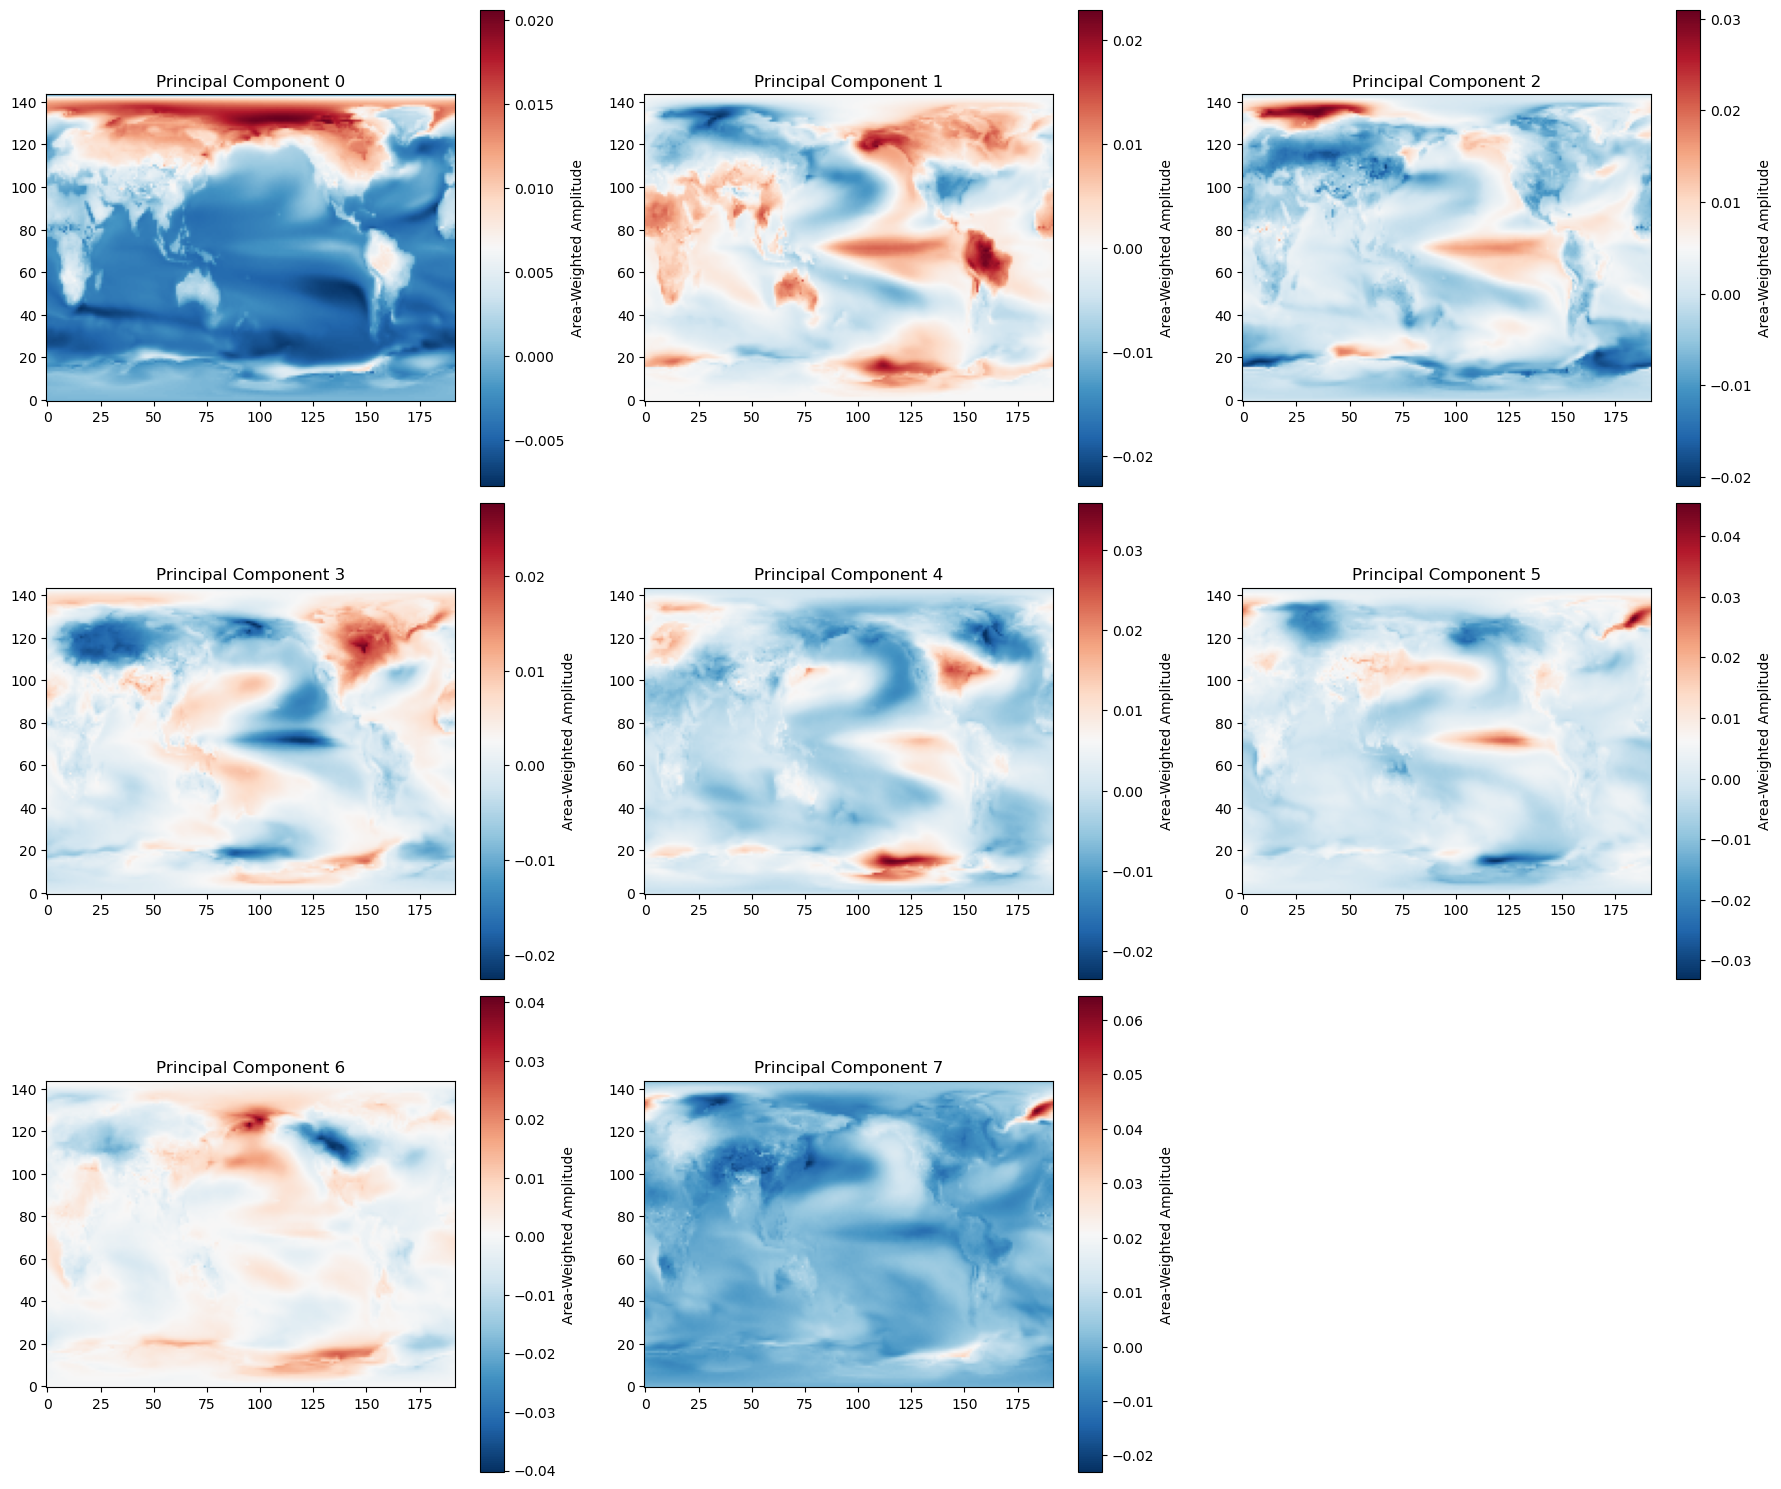

In [7]:
### To accelerate learning + ensure physical grounding, we initialise embedding layers with PCA values
### This means we need our PCA code back
# =========================================================
# FIXED PCA FUNCTION (Includes Latitude Cosine Weighting)
# =========================================================
def get_pcas(data_2d, latitudes, n_components=0.8, plot_pcs=True):
    """
    Accepts pre-stacked 2D numpy grid arrays (Years, Spatial_Points) and latitude vector.
    Scales features geometrically using cosine weighting, runs PCA, and returns weights.
    """
    # 1. CREATE AREA WEIGHTS: (144, 192) grid map based on physical latitude geometry
    # Cosine of latitude shrinks toward poles. We use sqrt so when variance is computed later (squared),
    # the linear area weight scales perfectly proportional to true geographic surface area.
    weights_1d = np.cos(np.deg2rad(latitudes))
    weights_1d = np.clip(weights_1d, 0, None)  # Safety clip to handle numerical precision at poles
    weights_2d = np.repeat(np.sqrt(weights_1d)[:, np.newaxis], 192, axis=1)
    flat_weights = weights_2d.flatten()          # Shape: (144 * 192,)
    
    # 2. APPLY WEIGHTING: Scale spatial variance naturally
    # Multiply every year's map row by the area weight vector row
    data_scaled = data_2d * flat_weights
    
    # 3. RUN PCA: Fit on the properly weighted spatial grids
    pca = PCA(n_components=n_components)
    pca_coefficients = pca.fit_transform(data_scaled)    
    
    # 4. RECONSTRUCT PATTERNS
    spatial_patterns = pca.components_.reshape(-1, 144, 192)
    
    if plot_pcs:
        print(f"Number of PCs chosen: {pca.n_components_}")
        print(f"Shape of coefficients for GP: {pca_coefficients.shape}")
        n_pcs = len(spatial_patterns)
        cols = 3
        rows = math.ceil(n_pcs / cols)
        fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
        axes = axes.flatten()
        
        for i in range(n_pcs):
            im = axes[i].imshow(spatial_patterns[i], cmap='RdBu_r', origin='lower')
            axes[i].set_title(f'Principal Component {i}')
            plt.colorbar(im, ax=axes[i], label='Area-Weighted Amplitude')
            
        for j in range(n_pcs, len(axes)):
            fig.delaxes(axes[j])
            
        plt.tight_layout()
        plt.show()
        
    return flat_weights, pca, pca_coefficients

# 1. Stack raw spatial inputs vertically
if hasattr(spatial_anomalies_sets[0], 'tas'):
    stacked = np.vstack([ds.tas.values.reshape(len(ds.tas['year']), -1) for ds in spatial_anomalies_sets])
    # Extract the 144 latitude values from your training structures
    latitudes = spatial_anomalies_sets[0].lat.values 
else:
    stacked = np.vstack(spatial_anomalies_sets)
    latitudes = np.linspace(-90, 90, 144) # Fallback if data is raw numpy

# 2. Get PCA patterns - NOW RETURNS THE GEOGRAPHIC WEIGHT VECTOR INSTEAD OF SCALER
flat_weights, pcas, pca_coefficients = get_pcas(stacked, latitudes, n_components=latent_size, plot_pcs=True)
# 3. Extract the components matrix (Shape will be: 8, 27648) -> 27648 is 144 * 192
pca_components_matrix = pcas.components_

In [8]:
### INSTEAD OF PCA, WE TRAIN A CNN ENCODER-DECODER
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [76]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AsymmetricCircularPadding(nn.Module):
    def __init__(self, pad_size=1):
        super(AsymmetricCircularPadding, self).__init__()
        self.pad_size = pad_size

    def forward(self, x):
        # 1. Apply circular padding ONLY horizontally (left/right for longitude loop)
        x = F.pad(x, (self.pad_size, self.pad_size, 0, 0), mode='circular')
        
        # 2. Apply constant zero padding vertically (top/bottom to isolate poles)
        x = F.pad(x, (0, 0, self.pad_size, self.pad_size), mode='replicate')#, value=0.0)
        return x

class ClimateVCAE(nn.Module):
    def __init__(self, latent_dim=8):
        super(ClimateVCAE, self).__init__()
        self.latent_dim = latent_dim
        
        # 1. ENCODER: Proportional channel scaling (1 -> 16 -> 32 -> 64)
        # Custom padding module isolates Arctic from Antarctic while wrapping East-West.
        self.encoder = nn.Sequential(
            # Stride 2 drops resolution from (144, 192) -> (72, 96)
            AsymmetricCircularPadding(pad_size=1),
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=0),   
            nn.ReLU(),
            
            # Stride 2 drops resolution from (72, 96) -> (36, 48)
            AsymmetricCircularPadding(pad_size=1),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=0),  
            nn.ReLU(),
            
            # Stride 2 drops resolution from (36, 48) -> (18, 24)
            AsymmetricCircularPadding(pad_size=1),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=0), 
            nn.ReLU(),
            nn.Flatten() # -> (64 * 18 * 24) = 27,648 features
        )
        
        # Proportional bottleneck paths matching your 27,648 PCA feature map
        self.fc_mu = nn.Linear(27648, latent_dim)       
        self.fc_logvar = nn.Linear(27648, latent_dim)   
        self.fc_decode = nn.Linear(latent_dim, 27648)
        
        # 2. DECODER: Proportional mirror upsampling
        # The custom padding is placed right after Upsample and right before Conv2d.
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64, 18, 24)),
            
            # Step 1: Scale from (18, 24) up to (36, 48)
            nn.Upsample(size=(36, 48), mode='bilinear', align_corners=False),
            AsymmetricCircularPadding(pad_size=1),
            nn.Conv2d(64, 32, kernel_size=3, padding=0),
            nn.ReLU(),
            
            # Step 2: Scale from (36, 48) up to (72, 96)
            nn.Upsample(size=(72, 96), mode='bilinear', align_corners=False),
            AsymmetricCircularPadding(pad_size=1),
            nn.Conv2d(32, 16, kernel_size=3, padding=0),
            nn.ReLU(),
            
            # Step 3: Scale back to your exact target size (144, 192)
            nn.Upsample(size=(144, 192), mode='bilinear', align_corners=False),
            AsymmetricCircularPadding(pad_size=1),
            nn.Conv2d(16, 1, kernel_size=3, padding=0) 
        )

    def reparameterize(self, mu, logvar):
        # Clamping logvar prevents numeric explosions during training
        std = torch.exp(0.5 * torch.clamp(logvar, -10, 10))
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        flat_features = self.encoder(x)
        mu = self.fc_mu(flat_features)
        logvar = self.fc_logvar(flat_features)
        
        z = self.reparameterize(mu, logvar)
        
        decoded_flat = self.fc_decode(z)
        reconstructed_map = self.decoder(decoded_flat)
        return reconstructed_map, mu, logvar


In [77]:
def inject_pca_into_climate_vcae(model, pca_components):
    """
    Injects PCA spatial patterns directly into the linear bottleneck of ClimateVCAE.
    
    Args:
        model: An instance of ClimateVCAE
        pca_components: Numpy array of shape (8, 27648) from your PCA code
    """
    # Convert your PCA numpy array to a PyTorch tensor
    pca_tensor = torch.tensor(pca_components, dtype=torch.float32)
    
    with torch.no_grad():
        # 1. ENCODER MU: Maps 27,648 features -> 8 latent components
        # PyTorch expects shape (out_features, in_features) -> (8, 27648)
        model.fc_mu.weight.copy_(pca_tensor)
        # Clear the biases to make it a pure projection initially
        model.fc_mu.bias.zero_()
        
        # 2. DECODER START: Maps 8 latent components -> 27,648 features
        # PyTorch expects shape (out_features, in_features) -> (27648, 8)
        model.fc_decode.weight.copy_(pca_tensor.T)
        model.fc_decode.bias.zero_()
        
        # 3. VARIANCE INITIALISATION (Optional but highly recommended)
        # Initialise logvar weights close to zero and bias to a small negative value (e.g., -2)
        # This makes the VCAE start with a predictable, small variance instead of wild random noise.
        model.fc_logvar.weight.fill_(0.0)
        model.fc_logvar.bias.fill_(-2.0)
        
    print("✅ Successfully injected 8 PCA spatial components into ClimateVCAE!")


In [78]:
use_pca_init = True

In [79]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import copy  # NEW: Required for taking deep copy snapshots of the weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active hardware target: {device}")

### Pass in the spatial anomaly maps that we trained PCA on to the CNN
# 1. Stack raw spatial inputs vertically
if hasattr(spatial_anomalies_sets[0], 'tas'):
    stacked = np.vstack([ds.tas.values.reshape(len(ds.tas['year']), -1) for ds in spatial_anomalies_sets])
    latitudes = spatial_anomalies_sets[0].lat.values 
else:
    stacked = np.vstack(spatial_anomalies_sets)
    latitudes = np.linspace(-90, 90, 144)

# 1. Create the linear area weights map
weights_1d = np.cos(np.deg2rad(latitudes))
weights_1d = np.clip(weights_1d, 0, None)
weights_2d = np.repeat(weights_1d[:, np.newaxis], 192, axis=1) # Shape: (144, 192)

# 2. Scale your stacked anomalies before feeding them into the CNN
flat_weights_linear = weights_2d.flatten()
#stacked_scaled_for_cnn = stacked * flat_weights_linear#####TODO : DO THE AREA WEIGHTING IN THE LOSS PART

# 3. Reshape, Convert to tensor and add the explicit 1-channel dimension for PyTorch Conv2D
#spatial_grids_np = stacked_scaled_for_cnn.reshape(-1, 144, 192)
spatial_grids_np = stacked.reshape(-1, 144, 192)
train_maps_tensor = torch.tensor(spatial_grids_np).float().unsqueeze(1)


# =========================================================================
# 🛠️ LAND MASK IMPLEMENTATION (ADDED HERE)
# =========================================================================
# 1. Calculate the standard deviation over time for every single pixel in your training maps.
pixel_variance = np.std(spatial_grids_np, axis=0)

# 2. Establish a threshold (40th percentile) to segment high-variance land from low-variance sea.
threshold = np.percentile(pixel_variance, 40)
land_mask_2d = np.where(pixel_variance > threshold, 1.0, 0.0)

# 3. Build the physical loss scaling matrix.
spatial_loss_weights_np = np.ones_like(land_mask_2d) + (land_mask_2d * 3.0)

# 4. Wrap to a native PyTorch tensor and move to your active hardware execution device.
spatial_loss_weights = torch.tensor(spatial_loss_weights_np).float().to(device)
# =========================================================================


# Set up clean PyTorch data loader pipeline
dataset = TensorDataset(train_maps_tensor)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)


Active hardware target: cuda


In [94]:
# =========================================================================
# VCAE INITIALIZATION (RE-BALANCED)
# =========================================================================
vcae_model = ClimateVCAE(latent_dim=latent_size).to(device) 

if use_pca_init:
    inject_pca_into_climate_vcae(vcae_model, pca_components_matrix)
    
    # 🛠️ FIX: DO NOT FREEZE PERMANENTLY FOR VAE. 
    # Let all parameters learn, but use a lower learning rate for the linear projections.
    optimizer = optim.Adam([
        {'params': vcae_model.encoder.parameters(), 'lr': 0.001},
        {'params': vcae_model.decoder.parameters(), 'lr': 0.001},
        {'params': vcae_model.fc_mu.parameters(), 'lr': 0.0001},      # Slower learning
        {'params': vcae_model.fc_logvar.parameters(), 'lr': 0.0001},  # Slower learning
        {'params': vcae_model.fc_decode.parameters(), 'lr': 0.0001}   # Slower learning
    ])
else:
    optimizer = optim.Adam(vcae_model.parameters(), lr=0.001)

# =========================================================================
# VCAE TRAINING LOOP WITH RE-SCALED LOSSES (CORRECTED)
# =========================================================================
best_recon_loss = float('inf')
best_model_weights = None

early_stop_patience = 20  
early_stop_counter = 0    
min_delta = 0.001          # Tighter delta for normalized scales

vcae_model.train()
total_epochs = 200

mse_l1_ratio = [0.3,0.7]
# 🛠️ FIX: Cap beta at a physically stable maximum instead of 10
beta_max = 0.001


# --- BEFORE THE LOOP: MERGE AREA WEIGHTS + LAND MASK (UPDATED WITH POLAR FLOOR) ---
# 1. Convert your 2D cosine weights map to a native tensor
area_weights_tensor = torch.tensor(weights_2d).float().to(device)

# 🛠️ REPLACE HERE: Apply the 0.20 floor constraint to protect the polar boundaries
safe_area_weights = np.clip(weights_2d, 0.20, None)

# 2. Multiply your land mask matrix by this stabilized weight matrix
combined_weights_np = (np.ones_like(land_mask_2d) + (land_mask_2d * 3.0)) * safe_area_weights

# 3. Wrap to tensor and reshape to (1, 1, 144, 192) for flawless batch broadcasting
spatial_loss_weights = torch.tensor(combined_weights_np).float().unsqueeze(0).unsqueeze(0).to(device)



for epoch in range(total_epochs):
    total_loss = 0
    total_recon_loss = 0
    total_kl_loss = 0
    
    # Smooth annealing schedule over the first 50 epochs
    beta = min(beta_max, (epoch / 50) * beta_max) 
    
    for batch in dataloader:
        maps = batch[0].to(device)
        optimizer.zero_grad()
        
        # 1. Forward Pass 
        outputs, mu, logvar = vcae_model(maps)
        
        # 🛠️ FIX: CLAMP LOGVAR IN LOSS CALCULATION TO PREVENT INF
        logvar_clamped = torch.clamp(logvar, -5, 2)
        
        # 2. Compute Reconstruction Loss (Normalized via .mean() to match KL magnitude)
        # --- SQUARED ERROR COMPONENT (MSE) ---
        squared_errors = (outputs - maps) ** 2 
        weighted_squared_errors = squared_errors * spatial_loss_weights
        mse_part = weighted_squared_errors.mean() # Changed from .sum() / batch_size
        
        # --- ABSOLUTE ERROR COMPONENT (L1) ---
        absolute_errors = torch.abs(outputs - maps) 
        weighted_absolute_errors = absolute_errors * spatial_loss_weights
        l1_part = weighted_absolute_errors.mean() # Changed from .sum() / batch_size
        
        # --- HYBRID RECONSTRUCTION BLEND ---
        recon_loss = (mse_l1_ratio[0] * mse_part) + (mse_l1_ratio[1] * l1_part)
        
        # 3. Compute KL Divergence Loss using clamped parameters
        kl_loss = -0.5 * torch.mean(torch.sum(1 + logvar_clamped - mu.pow(2) - logvar_clamped.exp(), dim=1))
        
        # 4. Total Loss
        loss = recon_loss + (beta * kl_loss)
        
        loss.backward()
        
        # 🛠️ FIX: Add gradient clipping to the VCAE to stop weight explosions
        torch.nn.utils.clip_grad_norm_(vcae_model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
        total_recon_loss += recon_loss.item()
        total_kl_loss += kl_loss.item()
        
    epoch_avg_recon = total_recon_loss / len(dataloader)
    
    if epoch_avg_recon < (best_recon_loss - min_delta):
        best_recon_loss = epoch_avg_recon
        best_model_weights = copy.deepcopy(vcae_model.state_dict())
        early_stop_counter = 0  
    else:
        early_stop_counter += 1 
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        avg_recon = total_recon_loss / len(dataloader)
        avg_kl = total_kl_loss / len(dataloader)
        print(f"VCAE Epoch [{epoch+1}/{total_epochs}] | "
              f"Normalized Recon Loss: {avg_recon:.5f} | "
              f"KL Div: {avg_kl:.5f} | "
              f"Beta: {beta:.5f}")

    if early_stop_counter >= early_stop_patience:
        print(f"\n[EARLY STOP] Triggered at Epoch {epoch+1}. No reconstruction improvement.")
        break


✅ Successfully injected 8 PCA spatial components into ClimateVCAE!
VCAE Epoch [1/200] | Normalized Recon Loss: 3.11110 | KL Div: 3711.53497 | Beta: 0.00000
VCAE Epoch [5/200] | Normalized Recon Loss: 0.88829 | KL Div: 280.96177 | Beta: 0.00008
VCAE Epoch [10/200] | Normalized Recon Loss: 0.79659 | KL Div: 90.12164 | Beta: 0.00018
VCAE Epoch [15/200] | Normalized Recon Loss: 0.72508 | KL Div: 56.70455 | Beta: 0.00028
VCAE Epoch [20/200] | Normalized Recon Loss: 0.69060 | KL Div: 47.96503 | Beta: 0.00038
VCAE Epoch [25/200] | Normalized Recon Loss: 0.66701 | KL Div: 38.70471 | Beta: 0.00048
VCAE Epoch [30/200] | Normalized Recon Loss: 0.67107 | KL Div: 34.70701 | Beta: 0.00058
VCAE Epoch [35/200] | Normalized Recon Loss: 0.65015 | KL Div: 30.29186 | Beta: 0.00068
VCAE Epoch [40/200] | Normalized Recon Loss: 0.64157 | KL Div: 27.88119 | Beta: 0.00078
VCAE Epoch [45/200] | Normalized Recon Loss: 0.63427 | KL Div: 26.68338 | Beta: 0.00088
VCAE Epoch [50/200] | Normalized Recon Loss: 0.63151

In [95]:

# =========================================================================
# VCAE POST-LOOP LOAD & LOCK STATE (CHANGED HERE)
# =========================================================================
# Force-load the absolute best performing snapshot back into the memory cells
if best_model_weights is not None:
    vcae_model.load_state_dict(best_model_weights)
    print(f"\n[SUCCESS] Recovered optimal model state! Locked in lowest Recon MSE: {best_recon_loss:.2f}")
else:
    print("\n[WARNING] No optimal weights dictionary state was recorded.")

# LOCK THE WEIGHTS PERMANENTLY
for param in vcae_model.parameters():
    param.requires_grad = False
vcae_model.eval()
print("VCAE Feature Extractor Training Complete and Locked.")


[SUCCESS] Recovered optimal model state! Locked in lowest Recon MSE: 0.50
VCAE Feature Extractor Training Complete and Locked.


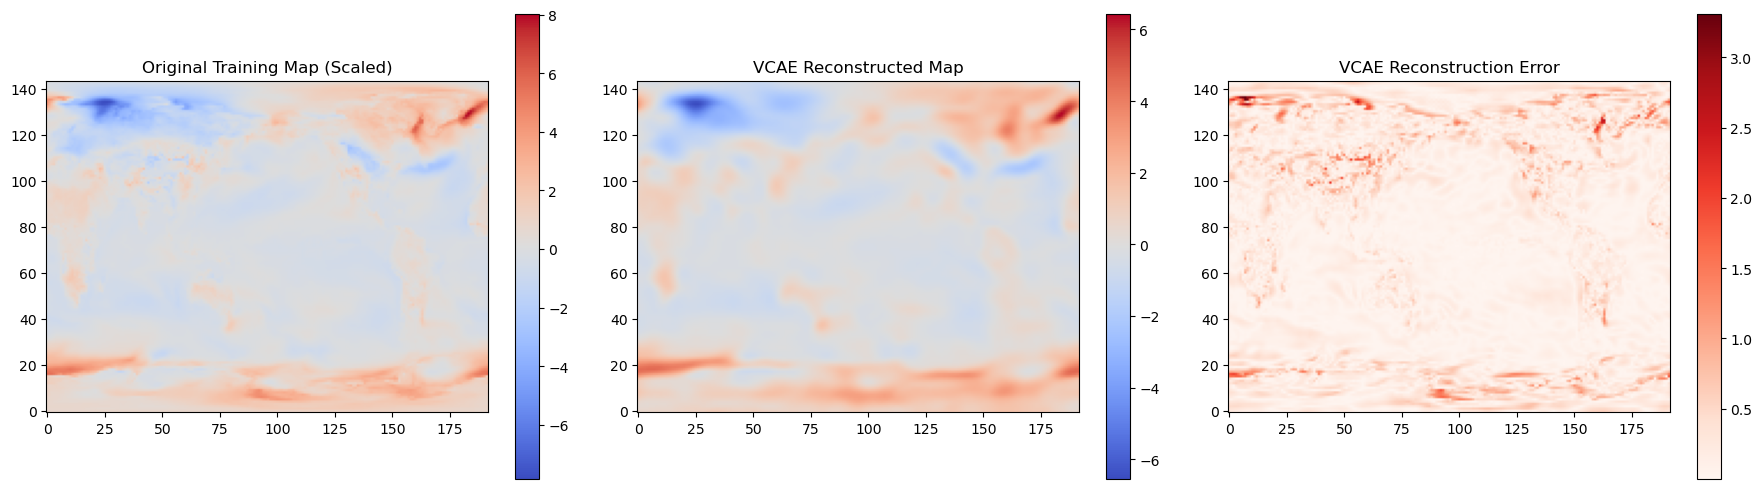

In [96]:
import matplotlib.pyplot as plt

def compare_recons(sample_map, vcae_model):
    vcae_model.eval()
    with torch.no_grad():
        # Pass through the model
        reconstructed_map, mu, logvar = vcae_model(sample_map)
        
        # Push back to CPU numpy for plotting
        orig_np = sample_map.squeeze().cpu().numpy()
        recon_np = reconstructed_map.squeeze().cpu().numpy()
        
    # 2. Calculate the direct difference mask
    absolute_error_map = np.abs(orig_np - recon_np)
    
    # 3. Plot side by side
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    im0 = axes[0].imshow(orig_np, cmap='coolwarm', origin='lower')
    axes[0].set_title('Original Training Map (Scaled)')
    fig.colorbar(im0, ax=axes[0])
    
    im1 = axes[1].imshow(recon_np, cmap='coolwarm', origin='lower')
    axes[1].set_title('VCAE Reconstructed Map')
    fig.colorbar(im1, ax=axes[1])
    
    im2 = axes[2].imshow(absolute_error_map, cmap='Reds', origin='lower')
    axes[2].set_title('VCAE Reconstruction Error')
    fig.colorbar(im2, ax=axes[2])
    
    plt.tight_layout()
    plt.show()


# 1. Grab a single map from your dataset (e.g., index 100)
sample_map = train_maps_tensor[100:101].to(device) # Keep batch dim: [1, 1, 144, 192]

compare_recons(sample_map, vcae_model)

In [97]:
"""
USE THIS CODE TO SAVE MODEL WEIGHTS
"""

import os

# =========================================================================
# 📁 NEW: AUTOMATIC UNIQUE DIRECTORY SELECTOR
# =========================================================================
# Define your base directory naming prefix
base_dir_name = "output"

# If the standard 'output' or 'output1' folder exists, find the next free number
if not os.path.exists(base_dir_name):
    target_dir = base_dir_name
else:
    n = 2
    while os.path.exists(f"{base_dir_name}{n}"):
        n += 1
    target_dir = f"{base_dir_name}{n}"

# Create the directory safely
os.makedirs(target_dir, exist_ok=True)
print(f"📦 Created new isolated run directory: {os.path.abspath(target_dir)}")


# =========================================================================
# 💾 MODEL WEIGHTS SAVING PIPELINE
# =========================================================================
# 1. Define the filename and route it into your new directory path
vcae_filename = f"vcae_model_latent_{latent_size}_ensembles.pt"
save_filepath = os.path.join(target_dir, vcae_filename)

# 2. Check if we have tracked the optimal weights snapshot
if best_model_weights is not None:
    # Save the deep-copied best weights dictionary directly to the new path
    torch.save(best_model_weights, save_filepath)
    print(f"[SUCCESS] Saved optimal VCAE weights to: {os.path.abspath(save_filepath)}")
else:
    # Fallback: Save the current state of the model if no tracker was populated
    torch.save(vcae_model.state_dict(), save_filepath)
    print(f"[FALLBACK] Saved current VCAE weights to: {os.path.abspath(save_filepath)}")


📦 Created new isolated run directory: /home/users/sa1013/output5
[SUCCESS] Saved optimal VCAE weights to: /home/users/sa1013/output5/vcae_model_latent_8_ensembles.pt


In [98]:
import pandas as pd

# 1. Extract the center mean coordinates (mu) for your entire training dataset
all_mu_list = []
vcae_model.eval()
with torch.no_grad():
    for batch in dataloader:
        maps = batch[0].to(device)
        _, mu, _ = vcae_model(maps)
        all_mu_list.append(mu.cpu().numpy())

all_mu_np = np.vstack(all_mu_list) # Shape: (Total_Years, 8)

# 2. Calculate the variance of each embedding channel over time
channel_variances = np.var(all_mu_np, axis=0)

# 3. Display as a quick dataframe
df_variance = pd.DataFrame({
    'Embedding_Channel': [f'Channel_{i}' for i in range(latent_size)],
    'Latent_Variance_Over_Time': channel_variances
})
print("--- VCAE Channel Activity Check ---")
print(df_variance)


--- VCAE Channel Activity Check ---
  Embedding_Channel  Latent_Variance_Over_Time
0         Channel_0                   0.483890
1         Channel_1                   0.232649
2         Channel_2                   0.289048
3         Channel_3                   0.409088
4         Channel_4                   0.251411
5         Channel_5                   0.486590
6         Channel_6                   0.562412
7         Channel_7                   0.292941


In [99]:
# =========================================================
# STEP 1: EXTRACT BOTH DISTRIBUTIONS FROM VCAE
# =========================================================
all_mu_list = []
all_var_list = []

vcae_model.eval()
with torch.no_grad():
    for matrix in spatial_anomalies_sets:
        # Reshape back to 4D grid required by your VCAE Conv2D layers
        grid_4d = torch.tensor(matrix.reshape(-1, 144, 192)).float().unsqueeze(1).to(device)
        
        # Pass through the encoder blocks to get both distribution vectors
        flat_features = vcae_model.encoder(grid_4d)
        mu_features = vcae_model.fc_mu(flat_features)
        logvar_features = vcae_model.fc_logvar(flat_features)
        
        # Convert log-variance back to standard variance (sigma^2 = exp(logvar))
        var_features = torch.exp(logvar_features)
        
        all_mu_list.append(mu_features.cpu().numpy())
        all_var_list.append(var_features.cpu().numpy())

# Stack them up to match scenario dimensions
all_mu_scaled = np.vstack(all_mu_list)   # Shape: (Total_Valid_Years, 16)
all_var_scaled = np.vstack(all_var_list) # Shape: (Total_Valid_Years, 16)

# Convert training scenarios to global mean values for X inputs
combined_x = np.concatenate(
    [ds.tas.mean(dim=['lat','lon']).values for ds in training_sets]
).reshape(-1, 1)

# =========================================================
# STEP 2: SPLIT BACK TO SCENARIOS TO BUILD LAGS SAFELY
# =========================================================
years_per_scenario = [len(scenario.year) for scenario in training_sets]

scaled_sets_x = []
scaled_sets_mu = []
scaled_sets_var = []
next_index = 0

for i in range(len(years_per_scenario)):
    current_index = next_index
    next_index = current_index + years_per_scenario[i]
    
    scaled_sets_x.append(combined_x[current_index:next_index])
    scaled_sets_mu.append(all_mu_scaled[current_index:next_index])
    scaled_sets_var.append(all_var_scaled[current_index:next_index])

def build_lagged_vae_dataset(scaled_x, scaled_mu, scaled_var, n_lags=3):
    num_years = len(scaled_x)
    lagged_x_list, sliced_mu_list, sliced_var_list = [], [], []
    
    for t in range(n_lags - 1, num_years):
        time_window = scaled_x[t - n_lags + 1 : t + 1]
        lagged_x_list.append(time_window.flatten())
        sliced_mu_list.append(scaled_mu[t])
        sliced_var_list.append(scaled_var[t])
        
    return np.array(lagged_x_list), np.array(sliced_mu_list), np.array(sliced_var_list)

# 1. Run the lagging function tracking the mean and variance components in parallel
processed_pairs = [
    build_lagged_vae_dataset(x, mu, var, n_lags=n_lags) 
    for x, mu, var in zip(scaled_sets_x, scaled_sets_mu, scaled_sets_var)
]

# 2. Scale X inputs
raw_train_x_stacked = np.vstack([pair[0] for pair in processed_pairs])
scaler_x = StandardScaler()
scaled_train_x_stacked = scaler_x.fit_transform(raw_train_x_stacked)

# ADDED DEFINITIONS: Extract and save your raw VCAE target arrays cleanly first
raw_train_mu_stacked = np.vstack([pair[1] for pair in processed_pairs])
raw_train_var_stacked = np.vstack([pair[2] for pair in processed_pairs])

# # 2. ADDED FIX: Natively scale your VCAE targets
scaler_y = StandardScaler()
scaled_train_mu_stacked = scaler_y.fit_transform(raw_train_mu_stacked)

# 3. Compile everything to native PyTorch tensors
train_x = torch.tensor(scaled_train_x_stacked).float()
# CHANGED: Pass the pre-scaled target matrix here instead of re-stacking the raw data!
train_mu = torch.tensor(scaled_train_mu_stacked).float() 

# OPTIMIZED: Use your pre-stacked variable here
train_var = torch.tensor(raw_train_var_stacked).float() 

# =========================================================
# STEP 3: PREPARE DIMENSIONS SPECIFICALLY FOR THE BATCH GP
# =========================================================
num_pcs = latent_size # 16

# Target targets: Transpose to [16, Total_Valid_Years]
train_y_model = train_mu.t().to(device)

# Target variances: Transpose to [16, Total_Valid_Years]
train_var_model = train_var.t().to(device)

# Training inputs: Replicated to [16, Total_Valid_Years, n_lags]
train_x_model = train_x.unsqueeze(0).repeat(num_pcs, 1, 1).to(device)


Below, we train our GPs as a batch. This outputs a batch where we have to use indexing to access the relevant GP for each PC, and then for each scenario.

In [100]:
class ClimateGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, input_dims):
        super(ClimateGPModel, self).__init__(train_x, train_y, likelihood)
        
        num_pcs = train_y.shape[0] 
        pc_batch_shape = torch.Size([num_pcs])
        
        # 1. MEAN FUNCTION WITH BIAS
        '''
        self.mean_module = gpytorch.means.LinearMean(
            input_size=input_dims, 
            batch_shape=pc_batch_shape,
            bias=True  # Kept True to learn the vertical intercepts!
        )
        '''
        # Change this in your __init__ so the mean function doesn't fight the new quadratic kernel
        self.mean_module = gpytorch.means.ConstantMean(batch_shape=pc_batch_shape)

        
        # 2. SHORT-TERM WEATHER / CHAOTIC VARIABILITY KERNEL (ARD Enabled)
        # Loose interval constraint lets your ARD parameters scale freely 
        # to find exactly which lookback year holds the most predictive power
        self.short_term_matern = gpytorch.kernels.MaternKernel(
            nu=1.5, 
            ard_num_dims=input_dims,
            batch_shape=pc_batch_shape,
            lengthscale_constraint=gpytorch.constraints.Interval(0.01, 10.0) 
        )
        self.short_term_scale = gpytorch.kernels.ScaleKernel(
            self.short_term_matern,
            batch_shape=pc_batch_shape
        )
        
        # 3. SMOOTH DECADAL CYCLE KERNEL (Decoupled and Additive)
        # Nu=2.5 creates much smoother cyclic oscillations (like El Niño/De-cadal trends)
        # Multiplying it by Periodic creates locally periodic variations that can change amplitude
        smooth_matern = gpytorch.kernels.MaternKernel(
            nu=2.5,
            batch_shape=pc_batch_shape,
            lengthscale_constraint=gpytorch.constraints.Interval(1.0, 15.0)
        )
        periodic = gpytorch.kernels.PeriodicKernel(
            batch_shape=pc_batch_shape,
            period_length_constraint=gpytorch.constraints.Interval(0.02, 0.5) 
        )
        self.cyclic_scale = gpytorch.kernels.ScaleKernel(
            smooth_matern * periodic,
            batch_shape=pc_batch_shape
        )
        
        # 4. LONG-TERM BACKGROUND TREND TRUCKER
        # Adding a Linear Kernel lets the model track multi-decadal shifts 
        # cleanly without relying solely on the mean function slope
        self.trend_scale = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.PolynomialKernel(power=2, batch_shape=pc_batch_shape),
            batch_shape=pc_batch_shape
        )

        # FIX: Combine the components additively so each handles a distinct physical trend!
        self.covar_module = self.short_term_scale + self.cyclic_scale + self.trend_scale

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


In [101]:
np.array(channel_variances)

array([0.48389012, 0.23264872, 0.28904757, 0.40908825, 0.2514111 ,
       0.4865898 , 0.56241155, 0.2929412 ], dtype=float32)

In [102]:
############ WEIGHTING GPS BY VARIANCE - DOESNT ACTUALLY HELP
"""
### Strategies for pruning outputs from VCAE before training the GP

# 1: drop channels that are too high in variance - how to decide?
'''
0         Channel_0                   9.840162
1         Channel_1                   2.479005
2         Channel_2                   8.292080
3         Channel_3                  17.492790
4         Channel_4                   6.209336
5         Channel_5                  12.340466
6         Channel_6                   4.555376
7         Channel_7                  24.611940
'''
drop_channels = False
inverse_variance = True
# =========================================================
# 1. COMPUTE PHYSICAL IMPORTANCE WEIGHTS 
# =========================================================
if drop_channels: # don't do this as results in misalignments with targets during testing - easier to weight high-variance components lower
    kept_channels = [0, 1, 2, 4, 6] 
    num_pcs = len(kept_channels)
    train_y_model = torch.tensor(scaled_train_mu_stacked).float().t()[kept_channels, :].to(device)
    train_var_model = torch.tensor(raw_train_var_stacked).float().t()[kept_channels, :].to(device)
    train_x_model = torch.tensor(scaled_train_x_stacked).float().unsqueeze(0).repeat(num_pcs, 1, 1).to(device)

    print(f"Strategy 1 Active: Training a Batch GP on {num_pcs} clean channels.")
    print(f"Slices compiled - train_x_model: {train_x_model.shape} | train_y_model: {train_y_model.shape}")    
else:
    num_pcs = latent_size
    if inverse_variance:
        inverse_variances = 1.0 / channel_variances
        normalized_weights = inverse_variances / np.sum(inverse_variances)
        loss_weights = torch.tensor(normalized_weights).float().to(device)

        print("Synchronized Inverse-Variance Loss Weights:")
        for i, w in enumerate(normalized_weights):
            print(f"  Channel_{i} -> Weight: {w:.4f}  (Variance was: {channel_variances[i]:.2f})")
        
normalized_weights = np.ones(num_pcs) / num_pcs
loss_weights = torch.tensor(normalized_weights).float().to(device)
"""

'\n### Strategies for pruning outputs from VCAE before training the GP\n\n# 1: drop channels that are too high in variance - how to decide?\n\'\'\'\n0         Channel_0                   9.840162\n1         Channel_1                   2.479005\n2         Channel_2                   8.292080\n3         Channel_3                  17.492790\n4         Channel_4                   6.209336\n5         Channel_5                  12.340466\n6         Channel_6                   4.555376\n7         Channel_7                  24.611940\n\'\'\'\ndrop_channels = False\ninverse_variance = True\n# =========================================================\n# 1. COMPUTE PHYSICAL IMPORTANCE WEIGHTS \n# =========================================================\nif drop_channels: # don\'t do this as results in misalignments with targets during testing - easier to weight high-variance components lower\n    kept_channels = [0, 1, 2, 4, 6] \n    num_pcs = len(kept_channels)\n    train_y_model = torch.tensor

In [103]:
print(train_var_model)

tensor([[1.7158e-05, 8.1619e-05, 2.0927e-05,  ..., 2.4499e-07, 1.9090e-07,
         2.4573e-07],
        [1.5633e-05, 3.9047e-05, 1.5513e-05,  ..., 1.3589e-06, 1.1787e-06,
         1.4132e-06],
        [1.0114e-05, 3.5567e-05, 1.5765e-05,  ..., 5.7377e-08, 4.6243e-08,
         4.8622e-08],
        ...,
        [1.7623e-05, 3.5069e-05, 1.5827e-05,  ..., 1.5110e-07, 1.2912e-07,
         1.3655e-07],
        [1.4285e-05, 3.0175e-05, 1.1582e-05,  ..., 6.7415e-06, 8.4229e-06,
         5.9781e-06],
        [1.9629e-05, 5.0769e-05, 1.9199e-05,  ..., 1.6804e-06, 1.9011e-06,
         1.8442e-06]], device='cuda:0')


In [104]:
import copy
import numpy as np

# =========================================================================
# 🛠️ CRITICAL REMEDIAL STEP: PURGE VCAE NUMERICAL COLLAPSE
# =========================================================================
# 1. Convert your array to a native tensor and transpose it as usual
train_var_model = torch.tensor(raw_train_var_stacked, dtype=torch.float32).t().to(device)

# 2. Replaced all raw 'inf' or 'NaN' elements with a safe fallback variance
# If a slot is infinity, we set it to 0.1 (a standard, healthy relative variance)
is_invalid = torch.isinf(train_var_model) | torch.isnan(train_var_model)
train_var_model[is_invalid] = 0.1

# 3. Enforce strict numerical bounds (The Clamping Shield)
# - Min floor (1e-3): Prevents division-by-zero or matrix singularity from tiny decimals
# - Max ceiling (1.0): Prevents massive exploding values from skewing the GP matrix
train_var_model = torch.clamp(train_var_model, min=1e-3, max=1.0)

print(f"🎯 Purge Complete! Max variance is now: {train_var_model.max().item():.3f} | Min is: {train_var_model.min().item():.3f}")

# =========================================================================
# 2. INITIALIZATION (VARIANCE-GUIDED HETEROSCEDASTIC SETUP)
# =========================================================================
likelihood = gpytorch.likelihoods.FixedNoiseGaussianLikelihood(
    noise=train_var_model,         # Now completely sanitized and safe!
    learn_additional_noise=True, 
    batch_shape=torch.Size([num_pcs])
).to(device)


model = ClimateGPModel(train_x_model, train_y_model, likelihood, input_dims=n_lags).to(device)

# =========================================================================
# 🛠️ CRITICAL FIX: MANUALLY CALIBRATE KERNEL STARTING POINTS
# =========================================================================
# This prevents the composite kernel (Matern + Cyclic + Trend) from initializing 
# with values that create singular, non-invertible covariance matrices.
with torch.no_grad():
    # 1. Anchor the Mean Module close to a neutral starting point
    model.mean_module.initialize(constant=torch.zeros(num_pcs).to(device))
    
    # 2. Prevent the short-term lengthscale from being too small (avoids division-by-zero)
    # We set it to a healthy 1D time-lag window baseline (e.g., 2.0 years)
    if hasattr(model, 'short_term_matern'):
        model.short_term_matern.initialize(lengthscale=torch.ones(num_pcs, 1, 1).to(device) * 2.0)
    if hasattr(model, 'short_term_scale'):
        model.short_term_scale.initialize(outputscale=torch.ones(num_pcs).to(device) * 0.5)
        
    # 3. Stabilise the Cyclic / Periodic parameters
    if hasattr(model, 'cyclic_scale'):
        model.cyclic_scale.initialize(outputscale=torch.ones(num_pcs).to(device) * 0.2)
        # Target the nested internal base kernels inside your cyclic string
        for sub_kernel in model.cyclic_scale.base_kernel.children():
            if hasattr(sub_kernel, 'initialize'):
                if 'lengthscale' in dict(sub_kernel.named_parameters()):
                    sub_kernel.initialize(lengthscale=torch.ones(num_pcs, 1, 1).to(device) * 5.0)
                if 'period_length' in dict(sub_kernel.named_parameters()):
                    sub_kernel.initialize(period_length=torch.ones(num_pcs, 1, 1).to(device) * 10.0)
                    
    # 4. Anchor the Long-Term Trend module
    if hasattr(model, 'trend_scale'):
        model.trend_scale.initialize(outputscale=torch.ones(num_pcs).to(device) * 0.5)
        if hasattr(model.trend_scale.base_kernel, 'initialize'):
            model.trend_scale.base_kernel.initialize(offset=torch.zeros(num_pcs, 1).to(device))

print("🎯 Success: Composite kernel parameters safely anchored to stable baselines!")


# Initialise Optimizer 
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=20, threshold=0.005, threshold_mode='rel'
)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model).to(device)

# =========================================================
# 3. TRAINING LOOP WITH STABILITY SAFEGUARDS
# =========================================================
patience = 50
min_delta = 0.0001
best_loss = float('inf')
best_model_weights = None  # NEW: Container to store our snapshot safely
counter = 0

model.train()
likelihood.train()
epochs = 5000

for i in range(epochs):
    optimizer.zero_grad()
    
    # Kept cholesky_jitter at 1e-4 since LR is a stable 0.01 now
    with gpytorch.settings.cholesky_jitter(1e-4):
        output = model(train_x_model)
        individual_pc_losses = -mll(output, train_y_model)
        loss = individual_pc_losses.mean() 

    loss.backward()
    
    # Enforce gradient clipping at 1.0 to shield multi-component kernels
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    
    optimizer.step()

    # STEP THE SCHEDULER
    scheduler.step(loss)
    current_lr = optimizer.param_groups[0]['lr']
    current_loss = loss.item()
    
    # =========================================================
    # 🛠️ NEW: BROKEN STATE GUARD & SAFE SNAPSHOTTING
    # =========================================================
    # Check if the loss or any model parameters contain NaNs before making a judgment
    has_nans = np.isnan(current_loss) or any(torch.isnan(p).any() for p in model.parameters())
    
    if not has_nans:
        if current_loss < best_loss - min_delta:
            best_loss = current_loss
            # Create a deep copy snapshot of the model weights ONLY while they are healthy
            best_model_weights = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
    else:
        print(f"\n⚠️ [CRITICAL] Numerical instability detected at Epoch {i+1}!")
        print("Skipping weight snapshot saving to protect the pipeline.")
        # If your learning rate is already very small, it's safer to break early
        if current_lr < 1e-5:
            print("Learning rate exhausted. Terminating training to recover best stable checkpoint.")
            break
        
    if counter >= patience:
        print(f'Early stopping at iteration {i+1}. Final LR: {current_lr:.6f}')
        break
        
    if i % 100 == 0:
        print(f'Epoch {i+1:04d}/{epochs} - Weighted Average Loss: {current_loss:.3f}; LR: {current_lr:.6f}')

# =========================================================
# 🛠️ NEW: POST-LOOP CHECKPOINT RECOVERY
# =========================================================
# Force-load the absolute best performing stable snapshot back into memory cells
if best_model_weights is not None:
    model.load_state_dict(best_model_weights)
    print(f"\n[SUCCESS] Recovered optimal, clean model state! Lowered Loss to: {best_loss:.4f}")
else:
    print("\n[WARNING] No optimal checkpoint dictionary was saved. Model may still contain NaNs.")

print("Training complete!")


🎯 Purge Complete! Max variance is now: 0.001 | Min is: 0.001
🎯 Success: Composite kernel parameters safely anchored to stable baselines!
Epoch 0001/5000 - Weighted Average Loss: 1.270; LR: 0.010000
Epoch 0101/5000 - Weighted Average Loss: 1.149; LR: 0.010000
Epoch 0201/5000 - Weighted Average Loss: 1.118; LR: 0.002500
Epoch 0301/5000 - Weighted Average Loss: 1.117; LR: 0.000078
Early stopping at iteration 347. Final LR: 0.000020

[SUCCESS] Recovered optimal, clean model state! Lowered Loss to: 1.1168
Training complete!


In [105]:
'''
CODE TO SAVE GP WEIGHTS 
'''

# Package both states together
checkpoint_data = {
    'model_state_dict': model.state_dict(),
    'likelihood_state_dict': likelihood.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),  # Optional: save if you want to resume training later
    'best_loss': best_loss
}

checkpoint_path = os.path.join(target_dir, "climate_gp_weights.pt")
torch.save(checkpoint_data, checkpoint_path)

print(f"🎉 Successfully saved model weights to: {checkpoint_path}")


🎉 Successfully saved model weights to: output5/climate_gp_weights.pt


In [106]:
def test(dataset_test):
    # =========================================================
    # --- 1. PREPARE TEST DATA (CORRECTED MIRROR MATCH) ---
    # =========================================================
    if dataset_test.lat.values[0] > dataset_test.lat.values[-1]:
        dataset_test = dataset_test.sortby('lat', ascending=True)
        print("Aligned test dataset latitude orientation from South to North.")
    
    test_global_mean_calculated = dataset_test.tas.mean(dim=['lat', 'lon'])
    test_x_np = dataset_test.tas_global.values.reshape(-1, 1)
    
    # --- DYNAMIC TOGGLE FOR TREND REMOVAL (MATCHES TRAINING) ---
    if remove_global_trend_prior:
        # Subtract the annual 1D area-weighted timeline from the 3D spatial map
        test_spatial_anomalies = dataset_test.tas - test_global_mean_calculated
        test_data_2d = test_spatial_anomalies.values.reshape(len(dataset_test.year), -1)
    else:
        # Keep absolute/long-term anomalies relative to 1850-1900 intact
        test_data_2d = dataset_test.tas.values.reshape(len(dataset_test.year), -1)
    
    test_data_2d_scaled = test_data_2d * flat_weights_linear
    test_data_3d_grid = test_data_2d_scaled.reshape(-1, 144, 192)
    
    test_maps_tensor = torch.tensor(test_data_3d_grid).float().unsqueeze(1).to(device)
    vcae_model.eval()
    with torch.no_grad():
        flat_features = vcae_model.encoder(test_maps_tensor)
        test_y_mu_tensor = vcae_model.fc_mu(flat_features)
        test_y_coefs = test_y_mu_tensor.cpu().numpy()  # Shape: (Test_Years, 8)
    
    # ─── THE FIXED SEQUENCING STEP ──────────────────────────────────────────
    raw_test_x_lagged, _, _ = build_lagged_vae_dataset(
        test_x_np, 
        test_y_coefs, 
        test_y_coefs, 
        n_lags=n_lags
    )
    
    test_x_scaled_matrix = scaler_x.transform(raw_test_x_lagged)
    test_y_coefs_scaled = scaler_y.transform(test_y_coefs)
    
    test_x_tensor = torch.tensor(test_x_scaled_matrix).float().to(device)
    test_x_model = test_x_tensor.unsqueeze(0).repeat(num_pcs, 1, 1)
    
    valid_test_years = len(test_x_scaled_matrix)
    test_y_ground_truth_scaled = test_y_coefs_scaled[-valid_test_years:]
    # ────────────────────────────────────────────────────────────────────────
    
    # =========================================================
    # --- 2. PERFORM PREDICTION ---
    # =========================================================
    model.eval()
    likelihood.eval()
    
    with torch.no_grad(), gpytorch.settings.fast_pred_var(), gpytorch.settings.cholesky_jitter(1e-5):
        observed_pred = likelihood(model(test_x_model))
        
        pred_means_raw = observed_pred.mean.cpu().numpy()     
        pred_stds_raw = observed_pred.stddev.cpu().numpy()   
    
        pred_means_scaled = pred_means_raw.T 
        pred_stds_scaled = pred_stds_raw.T

    # =========================================================
    # --- 4. SCORING (ON PROPERLY ALIGNED SCALES) ---
    # =========================================================
    print("\nMetrics relating to VCAE Latent Embeddings:")
    rmse = np.sqrt(mean_squared_error(test_y_ground_truth_scaled, pred_means_scaled))
    r2 = r2_score(test_y_ground_truth_scaled, pred_means_scaled)
    
    print(f"Total Test Embedding Latent RMSE: {rmse:.4f}")
    print(f"Total Test Embedding Latent R² Score: {r2:.4f}")
    
    # =========================================================
    # --- 3. DECODE OUTPUTS & RECONSTRUCT SPATIAL MAPS ---
    # =========================================================
    pred_means_unscaled = scaler_y.inverse_transform(pred_means_scaled)
    pred_means_tensor = torch.tensor(pred_means_unscaled).float().to(device)
    
    with torch.no_grad():
        decoded_flat = vcae_model.fc_decode(pred_means_tensor)
        decoded_maps_tensor = vcae_model.decoder(decoded_flat)
        pred_spatial_anomalies_scaled = decoded_maps_tensor.squeeze(1).cpu().numpy() 
    
    safe_weights_2d = np.where(weights_2d > 1e-4, weights_2d, 1.0)
    pred_spatial_anomalies = pred_spatial_anomalies_scaled / safe_weights_2d
    pred_spatial_anomalies[:, weights_2d <= 1e-4] = 0.0
    
    test_global_means_sliced = test_x_np[-valid_test_years:].reshape(-1, 1, 1)
    
    # --- DYNAMIC RECONSTRUCTION OUTPUT TOGGLE ---
    if remove_global_trend_prior:
        # Re-add the absolute annual global mean values since they were stripped at the front
        final_absolute_predictions = pred_spatial_anomalies + test_global_means_sliced
    else:
        # The decoded array is already an absolute/long-term physical anomaly field
        final_absolute_predictions = pred_spatial_anomalies 
        
    final_absolute_ground_truth = dataset_test.tas.values[-valid_test_years:]
    print("Prediction and Spatial Decoding complete!")
       

        # =========================================================
    # --- 4. SCORING (TRUE PHYSICAL BASELINE REGRESSION) ---
    # =========================================================
    # Hardcoded to ALWAYS execute the trend-removal method for an un-skewed 0.9°C / 1.2°C benchmark
    raw_train_maps_list = []
    for ds in training_sets:
        # 1. Enforce identical transposition layout to (year, lat, lon)
        trainset_weighted = apply_area_weighting(ds)
        
        # 2. ALWAYS extract the zero-global-mean grid anomalies for baseline training
        zero_mean_grid = trainset_weighted.tas - trainset_weighted.tas_global
        raw_train_maps_list.append(zero_mean_grid.values.reshape(len(ds.year), -1))
            
    raw_train_maps_stacked = np.vstack(raw_train_maps_list)
    
    # 3. Fit the linear pattern scaling baseline regressor natively on the trend-stripped grids
    baseline_regressor = LinearRegression()
    baseline_regressor.fit(combined_x, raw_train_maps_stacked)
    
    # 4. Predict the test scenario map sequence using the test global temperatures
    baseline_pred_flat = baseline_regressor.predict(test_x_np)
    baseline_spatial_maps = baseline_pred_flat[-valid_test_years:].reshape(-1, 144, 192)
    
    # 5. ALWAYS add back the area-weighted timeline slice to recover absolute physical temperature fields
    baseline_final_absolute_maps = baseline_spatial_maps + test_global_means_sliced
    
    # 6. Compute true baseline error comparison metrics
    baseline_squared_errors = (final_absolute_ground_truth - baseline_final_absolute_maps) ** 2
    pattern_scaling_rmse = np.sqrt(np.mean(baseline_squared_errors))
    print(f"Classic Linear Pattern Scaling Baseline RMSE : {pattern_scaling_rmse:.4f}°C")
    
    # Compute your pipeline's true spatial map absolute RMSE
    spatial_rmse = np.sqrt(mean_squared_error(
        final_absolute_ground_truth.flatten(), 
        final_absolute_predictions.flatten()
    ))
    print(f"True Spatial Map Absolute RMSE: {spatial_rmse:.4f}°C")            

    # =========================================================
    # --- 5. PLOTTING PREPARATION (UNSCALE VISUALS) ---
    # =========================================================
    test_y_ground_truth_unscaled = test_y_coefs[-valid_test_years:]
    pred_stds_unscaled = pred_stds_scaled * np.sqrt(scaler_y.var_)

    n_embeddings = num_pcs
    cols = 3
    rows = int(np.ceil(n_embeddings / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
    axes = axes.flatten()
    
    for i in range(n_embeddings):
        x_range = np.arange(len(pred_means_unscaled))
        
        axes[i].plot(test_y_ground_truth_unscaled[:, i], 'k-', label='Actual Embedding', alpha=0.6)
        axes[i].plot(pred_means_unscaled[:, i], 'r--', label='GP Mean', linewidth=1.5)
    
        lower_2std = pred_means_unscaled[:, i] - 2 * pred_stds_unscaled[:, i]
        upper_2std = pred_means_unscaled[:, i] + 2 * pred_stds_unscaled[:, i]
        axes[i].fill_between(x_range, lower_2std, upper_2std, color='red', alpha=0.1, label='95% Conf.')
    
        lower_1std = pred_means_unscaled[:, i] - 1 * pred_stds_unscaled[:, i]
        upper_1std = pred_means_unscaled[:, i] + 1 * pred_stds_unscaled[:, i]
        axes[i].fill_between(x_range, lower_1std, upper_1std, color='red', alpha=0.25, label='68% Conf.')
    
        axes[i].set_title(f'VCAE Embedding Channel {i}')
        axes[i].legend(loc='upper left', fontsize='small')
    
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    # =========================================================
    # --- 6. REGIONAL MAP ERROR HEATMAPS ---
    # =========================================================
    baseline_pixel_rmse = np.sqrt(np.mean((final_absolute_ground_truth - baseline_final_absolute_maps) ** 2, axis=0))
    gp_pixel_rmse = np.sqrt(np.mean((final_absolute_ground_truth - final_absolute_predictions) ** 2, axis=0))
    error_difference = baseline_pixel_rmse - gp_pixel_rmse
    
    fig, axes = plt.subplots(1, 3, figsize=(24, 6))
    
    im0 = axes[0].imshow(baseline_pixel_rmse, cmap='YlOrRd', origin='lower', vmin=0, vmax=2.5)
    axes[0].set_title('Classic Pattern Scaling Regional RMSE', fontweight='bold', fontsize=12)
    fig.colorbar(im0, ax=axes[0], label='Absolute Error (°C)', shrink=0.75)
    
    im1 = axes[1].imshow(gp_pixel_rmse, cmap='YlOrRd', origin='lower', vmin=0, vmax=2.5)
    axes[1].set_title('Gaussian Process Regional RMSE', fontweight='bold', fontsize=12)
    fig.colorbar(im1, ax=axes[1], label='Absolute Error (°C)', shrink=0.75)
    
    im2 = axes[2].imshow(error_difference, cmap='RdBu', origin='lower', vmin=-1.0, vmax=1.0)
    axes[2].set_title('Performance Delta\n(Baseline Error - GP Error)', fontweight='bold', fontsize=12)
    fig.colorbar(im2, ax=axes[2], label='GP Performance Margin (°C)\n[Blue = GP Wins | Red = Baseline Wins]', shrink=0.75)
    
    for ax in axes:
        ax.set_xlabel('Longitude Grid Index')
        ax.set_ylabel('Latitude Grid Index')
    
    plt.tight_layout()
    plt.show()

    ###########################################################
    #============== Uncertainty Quantification ===============#
    ###########################################################

    vcae_model.eval()
    with torch.no_grad():
        flat_features_uq = vcae_model.encoder(test_maps_tensor)
        test_y_logvar_tensor = vcae_model.fc_logvar(flat_features_uq)
        vcae_spatial_variance_raw = torch.exp(test_y_logvar_tensor).cpu().numpy()[-valid_test_years:]
        
    with torch.no_grad():
        gp_additional_noise = likelihood.second_noise_covar.noise.cpu().numpy().reshape(-1, 1)
        
    total_latent_variance = (pred_stds_unscaled ** 2) + gp_additional_noise.T + vcae_spatial_variance_raw
    total_latent_std = np.sqrt(total_latent_variance) 

    upper_latent_bound = pred_means_unscaled + (2.0 * total_latent_std)
    lower_latent_bound = pred_means_unscaled - (2.0 * total_latent_std)
    
    upper_bound_tensor = torch.tensor(upper_latent_bound).float().to(device)
    lower_bound_tensor = torch.tensor(lower_latent_bound).float().to(device)
    
    with torch.no_grad():
        upper_decoded = vcae_model.decoder(vcae_model.fc_decode(upper_bound_tensor)).squeeze(1).cpu().numpy()
        lower_decoded = vcae_model.decoder(vcae_model.fc_decode(lower_bound_tensor)).squeeze(1).cpu().numpy()
        
    upper_absolute_maps = upper_decoded / safe_weights_2d
    lower_absolute_maps = lower_decoded / safe_weights_2d
    upper_absolute_maps[:, weights_2d <= 1e-4] = 0.0
    lower_absolute_maps[:, weights_2d <= 1e-4] = 0.0
    
    if remove_global_trend_prior:
        upper_absolute_maps += test_global_means_sliced
        lower_absolute_maps += test_global_means_sliced

    print("✅ Full Spatial Uncertainty Quantification matrices successfully computed!")
    
    # ─── THE FINAL RETURN STATEMENT FOR THE WHOLE FUNCTION ───
    return final_absolute_predictions, final_absolute_ground_truth, upper_absolute_maps, lower_absolute_maps


Test for dataset SSP37O

Metrics relating to VCAE Latent Embeddings:
Total Test Embedding Latent RMSE: 0.8899
Total Test Embedding Latent R² Score: -3.9216
Prediction and Spatial Decoding complete!
Classic Linear Pattern Scaling Baseline RMSE : 0.8922°C
True Spatial Map Absolute RMSE: 39.9936°C


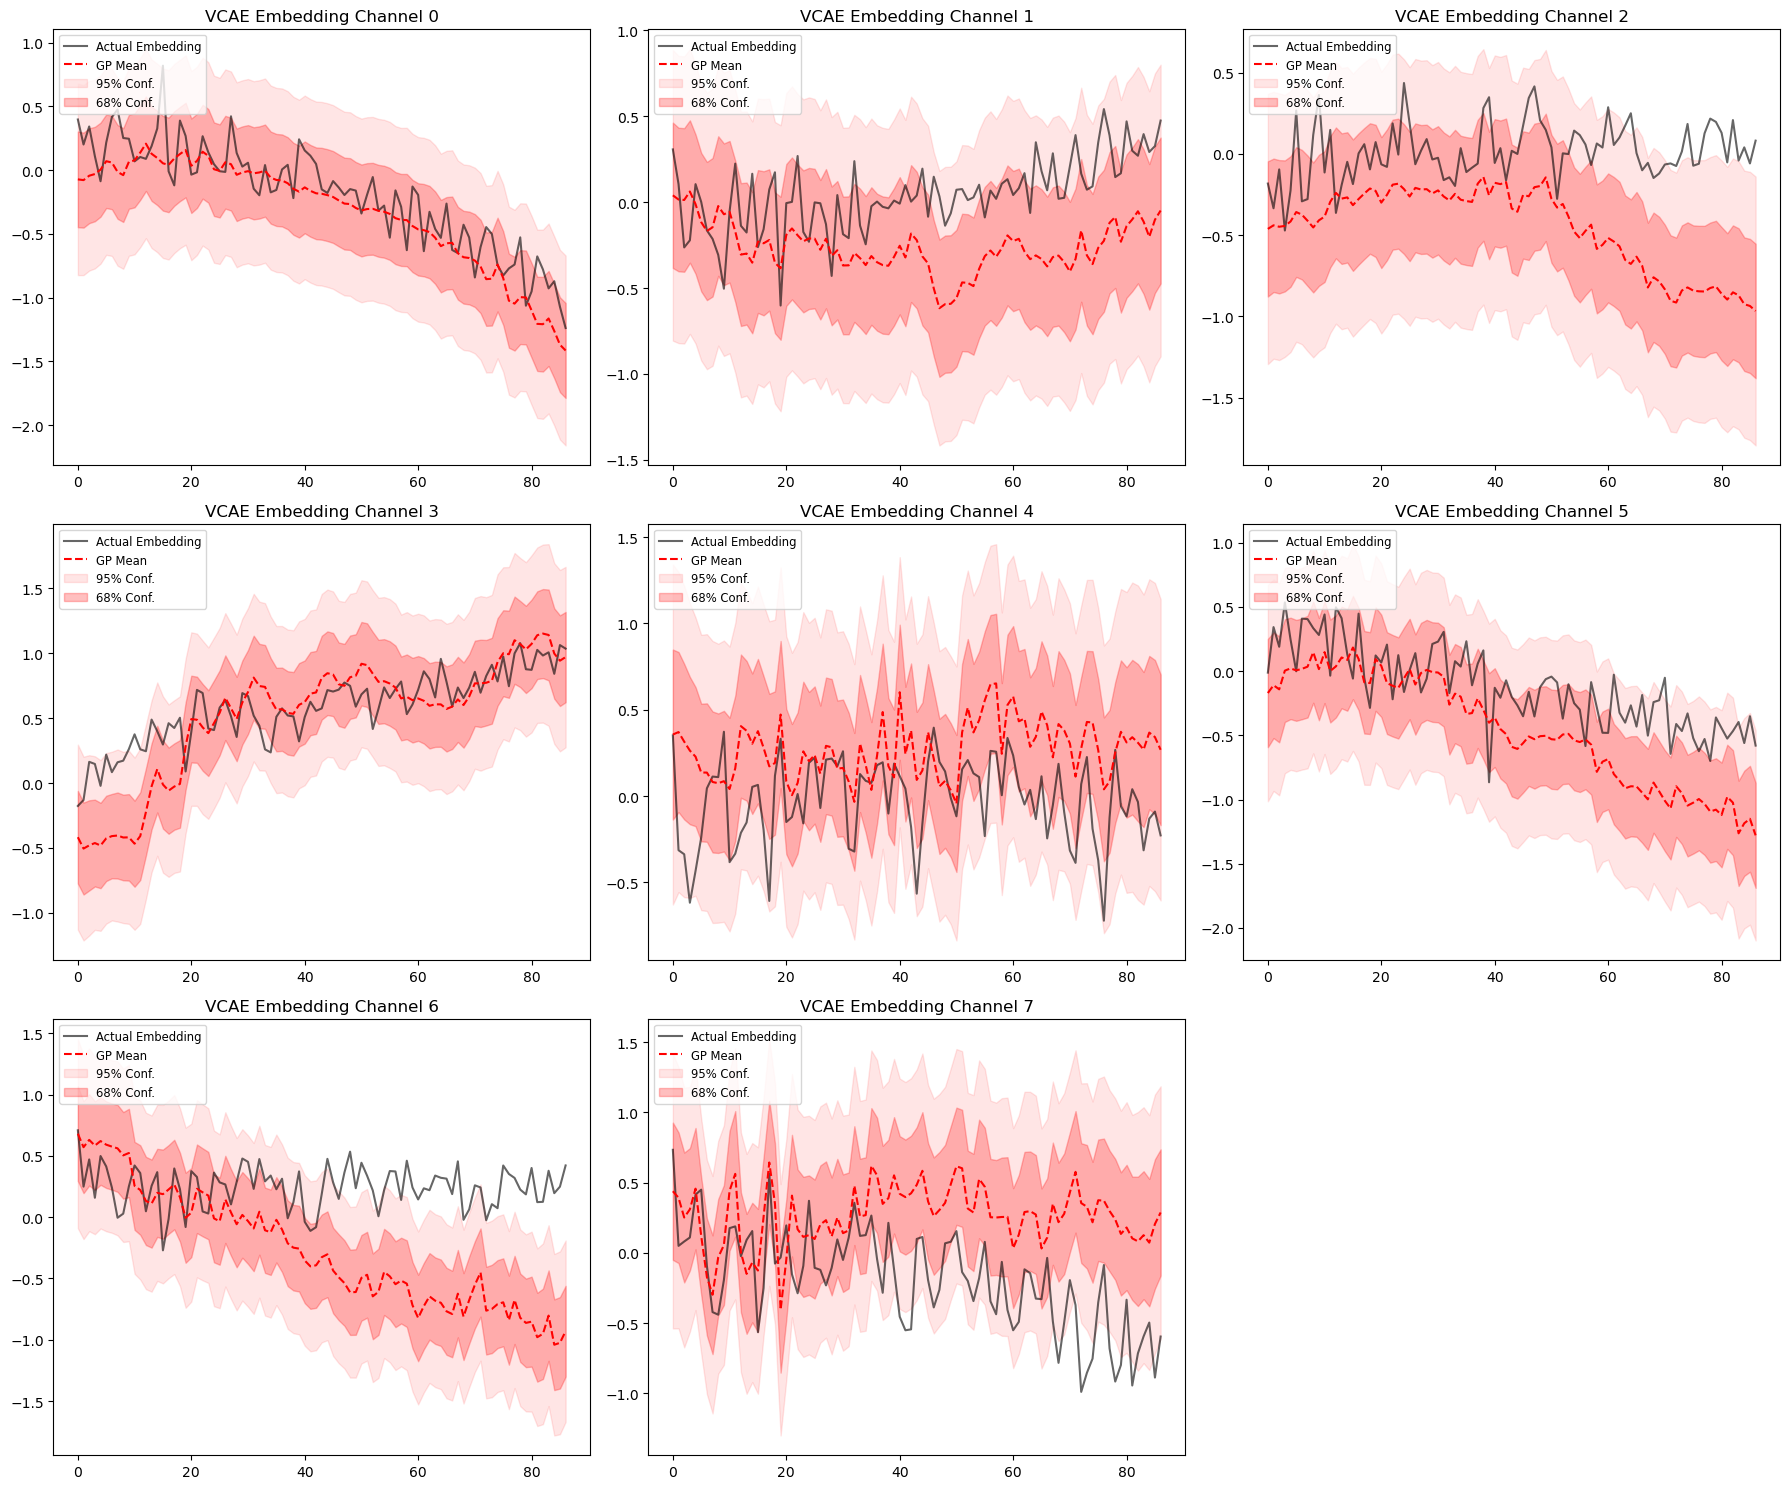

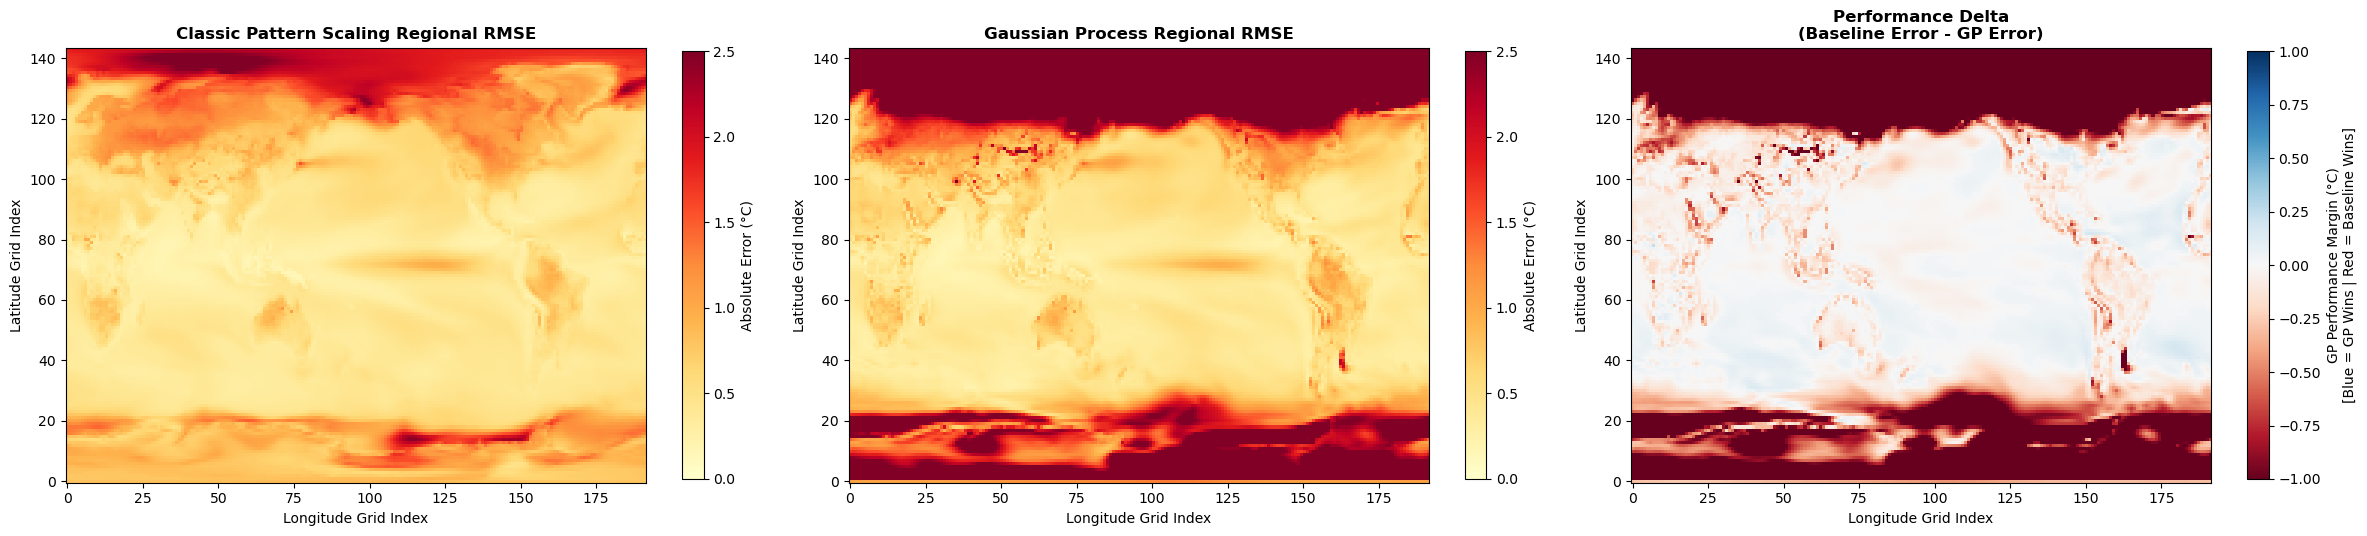

✅ Full Spatial Uncertainty Quantification matrices successfully computed!
Test for dataset SSP534-os

Metrics relating to VCAE Latent Embeddings:
Total Test Embedding Latent RMSE: 0.8642
Total Test Embedding Latent R² Score: -5.4641
Prediction and Spatial Decoding complete!
Classic Linear Pattern Scaling Baseline RMSE : 1.2586°C
True Spatial Map Absolute RMSE: 39.6136°C


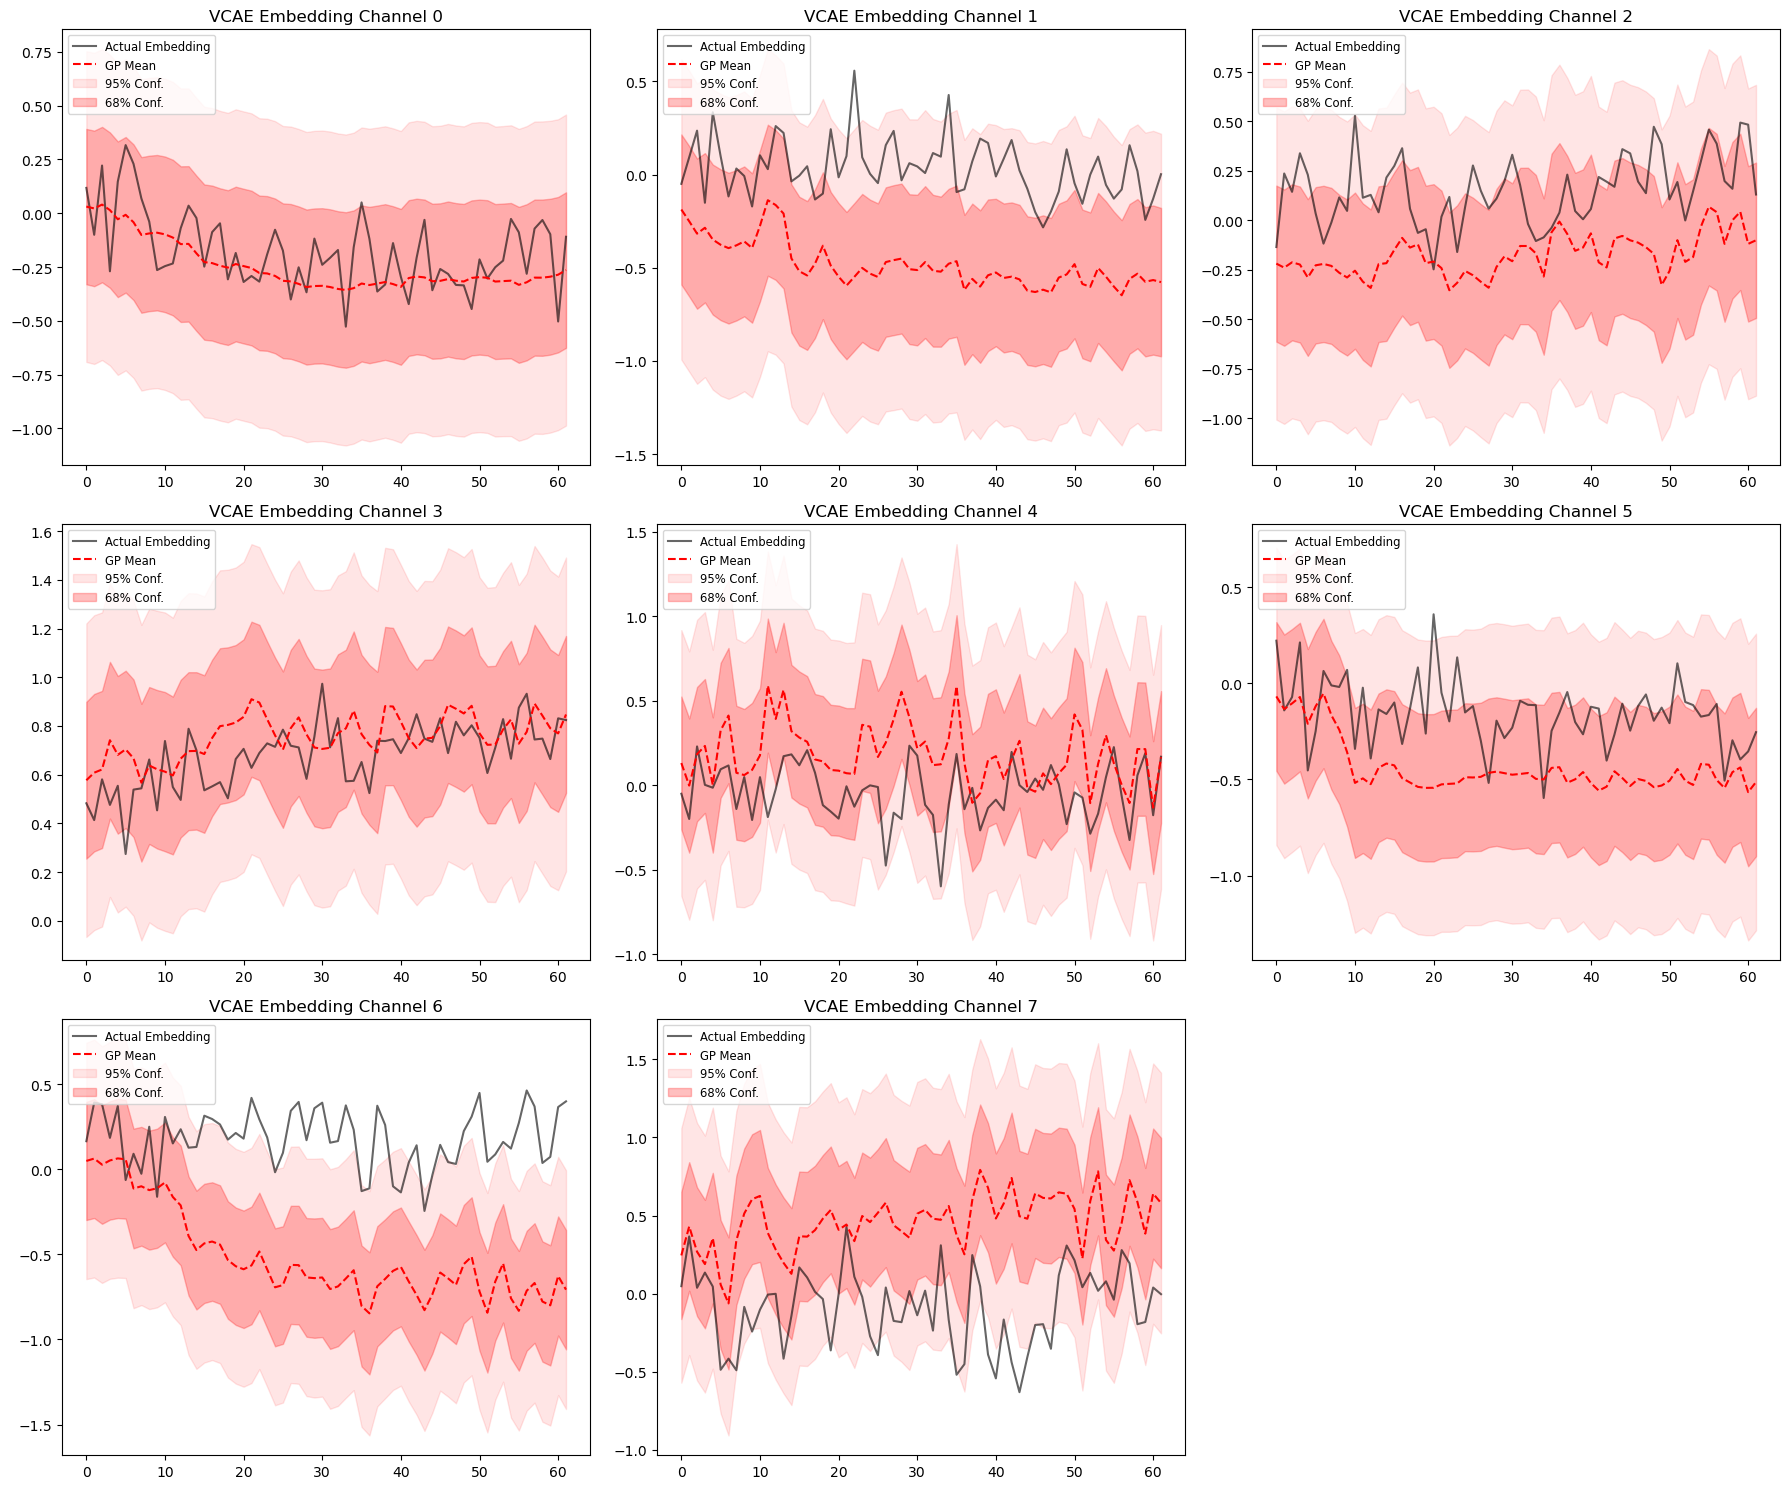

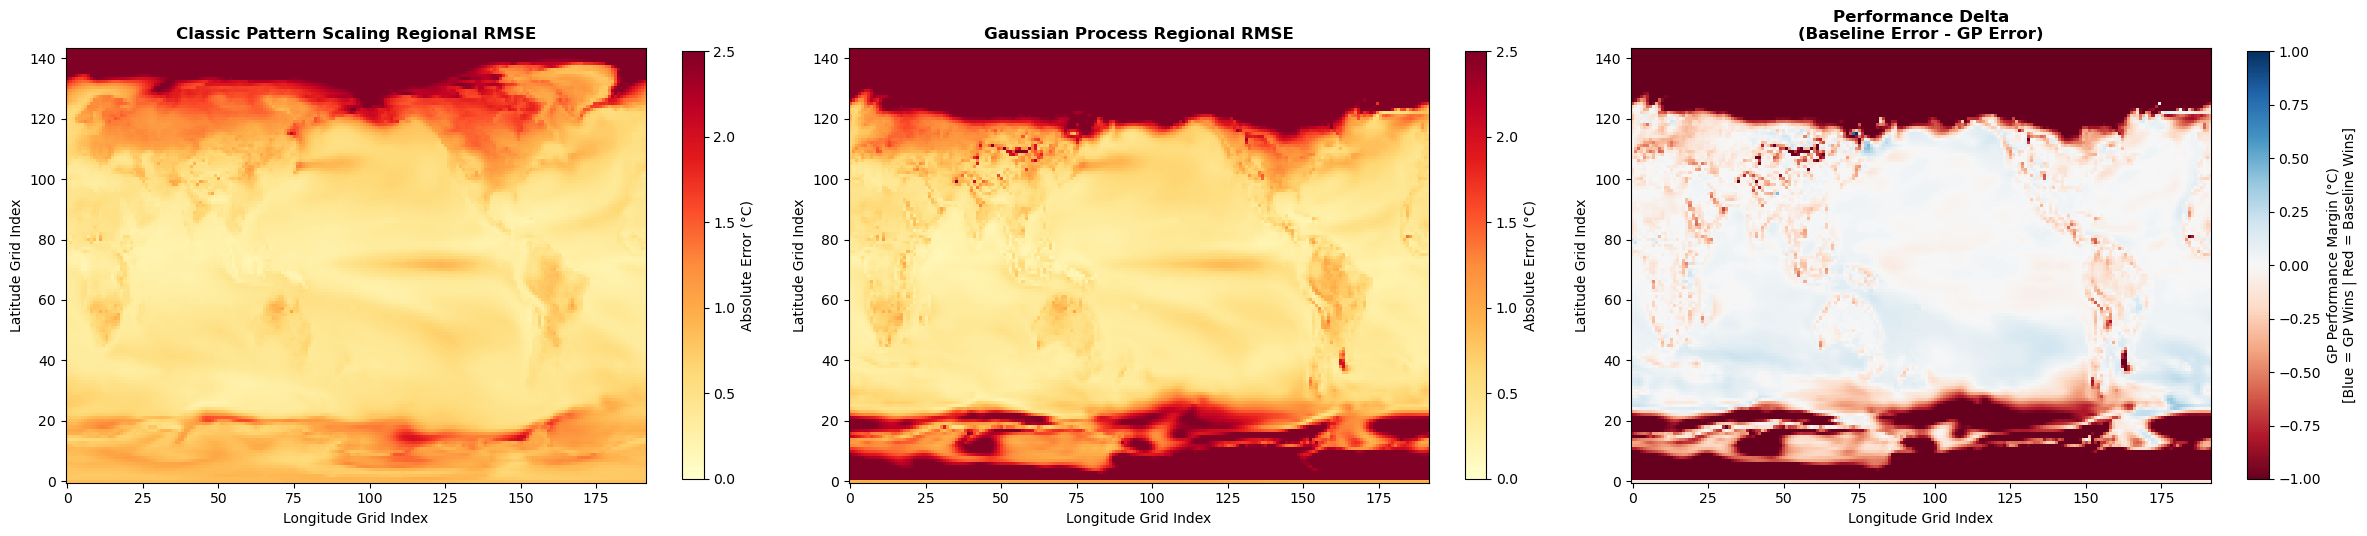

✅ Full Spatial Uncertainty Quantification matrices successfully computed!


(array([[[  2.48080066,   2.48080066,   2.48080066, ...,   2.48080066,
            2.48080066,   2.48080066],
         [ 25.87110525,  25.69689104,  26.02916706, ...,  28.9108254 ,
           29.17698593,  27.29763386],
         [ 12.77632596,  12.82228579,  13.03628891, ...,  14.1752558 ,
           14.25740785,  13.39015815],
         ...,
         [117.63031197, 118.24374656, 118.41458593, ..., 114.01943191,
          115.45992358, 116.71219557],
         [229.96718929, 230.30088438, 230.05520943, ..., 224.74636863,
          227.30689726, 228.97986598],
         [  2.48080066,   2.48080066,   2.48080066, ...,   2.48080066,
            2.48080066,   2.48080066]],
 
        [[  2.6672667 ,   2.6672667 ,   2.6672667 , ...,   2.6672667 ,
            2.6672667 ,   2.6672667 ],
         [ 31.14338251,  30.88469176,  31.20801654, ...,  34.5284786 ,
           35.01057337,  32.82847707],
         [ 15.72994032,  15.76477691,  15.99225289, ...,  17.20583715,
           17.39982131,  16.4308

In [107]:

## TESTS ##

print("====================\nTest for dataset SSP37O\n============")
test(validation_set)
print("Test for dataset SSP534-os\n================")
test(dataset_test)


In [ ]:
import torch
import gpytorch

# 1. RE-CREATE THE EXACT LIKELIHOOD AND MODEL STRUCTURE
# The dimensions and constraints must perfectly match your training setup
new_likelihood = gpytorch.likelihoods.GaussianLikelihood(
    batch_shape=torch.Size([num_pcs]),
    noise_constraint=gpytorch.constraints.Interval(1e-5, 1e-3)
).to(device)

# Ensure train_x_model and train_y_model tensors match original shapes
new_model = ClimateGPModel(
    train_x_model, 
    train_y_model, 
    new_likelihood, 
    input_dims=n_lags
).to(device)

# 2. LOAD THE SAVE FILE FROM DISK
checkpoint_path = "./gp_checkpoints/climate_gp_weights.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

# 3. INJECT THE WEIGHTS
new_model.load_state_dict(checkpoint['model_state_dict'])
new_likelihood.load_state_dict(checkpoint['likelihood_state_dict'])

# 4. SWITCH TO EVALUATION MODE
# This step is critical: it tells GPyTorch to transition from training log-likelihoods 
# to computing predictive posterior distributions.
new_model.eval()
new_likelihood.eval()

print("🚀 Weights successfully loaded! Model is ready for climate inference.")


In [ ]:
"""
USE THIS CODE TO LOAD WEIGHTS FROM A FILE - VCAE
"""
load_model = False
if load_model:
    # 1. Instantiate an empty model structure with matching structural parameters
    loaded_vcae = ClimateVCAE(latent_dim=8).to(device)
    
    # 2. Point to your saved checkpoint file
    checkpoint_path = "vcae_model_latent_8_ensembles.pt"
    
    # 3. Safely load the state dictionary across memory cells
    if os.path.exists(checkpoint_path):
        # map_location ensures it loads smoothly whether you are switching between CPU VM and GPU VM
        state_dict = torch.load(checkpoint_path, map_location=device)
        loaded_vcae.load_state_dict(state_dict)
        
        # Permanently freeze gradients and lock it into evaluation mode for feature extraction
        for param in loaded_vcae.parameters():
            param.requires_grad = False
        loaded_vcae.eval()
        
        print("[SUCCESS] VCAE checkpoint successfully reloaded and locked for testing!")
    else:
        print(f"[ERROR] Checkpoint file not found at: {checkpoint_path}")
